In [1]:
# ============================================================
# EDA PRINCIPAL - Retroviral Wall Challenge
# ============================================================
# Objetivo:
# Explorar train.csv desde una perspectiva estadística y bioinformática,
# entendiendo:
# 1) distribución de targets
# 2) composición por familias evolutivas
# 3) comportamiento de las features biofísicas
# 4) missing values estructurales
# 5) señales potencialmente útiles vs señales peligrosas por leakage de familia
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Configuración visual
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

# 2) Definir paths y cargar datasets

In [2]:
# =========================
# Paths de entrada
# =========================
TRAIN_DIR = "/kaggle/input/datasets/damontoyat/retroviral-train"
FAMILY_DIR = "/kaggle/input/datasets/damontoyat/retroviral-family-splits"
FEAT_DICT_DIR = "/kaggle/input/datasets/damontoyat/retroviral-feature-dic"

train_path = os.path.join(TRAIN_DIR, "train.csv")
family_path = os.path.join(FAMILY_DIR, "family_splits.csv")
feat_dict_path = os.path.join(FEAT_DICT_DIR, "feature_dictionary.csv")

# =========================
# Carga de archivos
# =========================
train_df = pd.read_csv(train_path)
family_df = pd.read_csv(family_path)
feat_dict_df = pd.read_csv(feat_dict_path)

print("train_df shape:", train_df.shape)
print("family_df shape:", family_df.shape)
print("feat_dict_df shape:", feat_dict_df.shape)

train_df shape: (57, 71)
family_df shape: (7, 5)
feat_dict_df shape: (66, 2)


# 3) Vista inicial de los datos

In [3]:
# Primer vistazo a cada dataset
display(train_df.head())
display(family_df.head())
display(feat_dict_df.head())

,rt_name,sequence,active,pe_efficiency_pct,protein_length_aa,perplexity,instability_index,gravy,t40_raw,t45_raw,t50_raw,t55_raw,t60_raw,t65_raw,t70_raw,t75_raw,t80_raw,thermophilicity_num,triad_found_bin,D1_D2_dist,D2_D3_dist,triad_best_rmsd,hydrophobic_per_res,salt_per_res,hbonds_per_res,pocket_hydrophobic_per_res,pocket_hbonds_per_res,whole_mean_hydrophobicity,whole_std_hydrophobicity,yxdd_hydrophobic_fraction,yxdd_mean_hydrophobicity,hairpin_pass,yxdd_y_is_strand,yxdd_x_is_turn,yxdd_d1_is_turn,yxdd_d2_is_strand,foldseek_best_TM,foldseek_best_LDDT,foldseek_best_fident,foldseek_TM_HIV1,foldseek_TM_MMLV,foldseek_TM_MMLVPE,foldseek_TM_Retron,foldseek_TM_LTRRetrotransposon,foldseek_TM_Group2Intron,foldseek_TM_Telomerase,seq_length,log_likelihood,net_charge,camsol,helix_beta_ratio,yxdd_std_hydrophobicity,n_residues,sasa_per_res,apolar_ratio,mean_rsasa,pocket_mean_rsasa,nterm_avg_sasa,rama_fav,rama_out,hairpin_confidence,yxdd_seq,overall_mean_pot,fingers_mean_pot,motif12_mean_pot,lpqg_sp_3A_mean_pot,yxdd_5A_mean_pot,palm_mean_pot,thumb_mean_pot,connection_mean_pot,rt_family
0,A.platensis-Cas1-RT,GDALLAAWYQVRTRSKTAGIDGISVELFAHFLDEELKRLAHQLQQD...,0,0.0,278,7.073275,41.651835,0.011871,0.87970,0.82760,0.822800,0.814300,0.492600,0.195400,0.130900,0.079320,3.345000e-02,2,1.0,11.5889,3.8325,7.4584,0.586,0.0216,1.565,0.409,0.545,0.0119,3.1276,0.6667,1.2889,1,1.0,1.0,1.0,1.0,0.9380,0.7883,0.281,0.7081,0.6936,0.6689,0.8251,0.5711,0.9380,0.8278,278,-1.956324,-3,0.277500,0.758621,2.8154,278.0,53.797554,0.537,0.2728,0.0918,117.61,94.7,0.0,0.727,YGDD,-2.0977,2.3503,13.7854,5.0225,-8.1501,-7.3936,-6.1497,NaN,CRISPR-associated
1,CRISPRRT2-RT,ISSQFIDINNFQRAWEKVADKRGCAGVDGETISSFASNQTVNVYQL...,0,0.0,319,5.294906,29.598746,-0.215987,0.20640,0.12780,0.064720,0.042930,0.018970,0.013300,0.004877,0.002055,5.113000e-04,0,1.0,14.9349,3.8714,9.4629,0.552,0.0219,1.542,0.478,0.478,-0.2160,3.2503,0.6842,1.2947,1,1.0,1.0,1.0,1.0,0.9155,0.7941,0.248,0.6902,0.6958,0.5897,0.8520,0.5512,0.9155,0.7676,319,-1.666745,4,0.533760,0.701613,2.7820,319.0,57.389655,0.538,0.2860,0.1039,111.41,91.0,0.3,0.664,YADD,1.6170,4.1130,14.7995,19.3829,-8.8022,-5.7010,13.9471,NaN,CRISPR-associated
2,FuRT-Cas1-RT,HVSELEKYWRMNHDQIISDLKNQEYQPGIILIREHMNKTGKRRNIA...,0,0.0,240,8.801058,44.682917,-0.371250,0.58790,0.50060,0.512400,0.629000,0.638600,0.250000,0.238700,0.155700,1.713000e-02,2,0.0,NaN,NaN,NaN,0.467,0.0292,1.550,0.000,0.000,-0.3713,3.2801,NaN,NaN,1,0.0,0.0,0.0,0.0,0.9591,0.8716,0.315,0.7017,0.6888,0.7105,0.8485,0.6740,0.9591,0.8070,240,-2.174872,-2,1.013978,0.814433,NaN,240.0,57.662042,0.529,0.2760,0.0000,112.56,95.5,0.4,0.659,NaN,-0.1282,2.3308,12.4422,10.9865,NaN,-2.5362,NaN,NaN,CRISPR-associated
3,Med-CasRT,GQYQLQDAYGYCSYPRPQAAKSLLEKSLSDASLHQACQTMYPRQAN...,0,0.0,311,9.759672,39.556913,-0.538585,0.02335,0.01206,0.005841,0.005216,0.000562,0.000232,0.000180,0.000083,3.193000e-05,0,1.0,11.7362,3.8473,7.0304,0.444,0.0547,1.524,0.261,0.609,-0.5386,3.0828,0.4737,0.4632,1,1.0,1.0,1.0,1.0,0.9118,0.7886,0.274,0.7043,0.6990,0.6731,0.8261,0.5437,0.9118,0.7207,311,-2.278259,-11,1.259983,0.990909,3.0660,311.0,60.705241,0.517,0.3009,0.0996,145.07,87.7,0.4,0.652,YADD,-3.4352,0.8252,-0.8038,14.4157,-10.5477,-9.0296,-6.7881,NaN,CRISPR-associated
4,ROSE-CRISPR-RT,PLFPRYNGPPLLPQICSVENLTLAWRRVRSNIHVARRGRSAGPDAV...,0,0.0,446,8.033197,43.787220,-0.152242,0.28120,0.22260,0.138500,0.032820,0.002112,0.002367,0.001416,0.000006,4.760000e-07,0,0.0,NaN,NaN,NaN,0.439,0.0314,1.592,0.500,0.583,-0.1522,3.0990,NaN,NaN,1,0.0,0.0,0.0,0.0,0.8861,0.7400,0.188,0.6718,0.6757,0.5978,0.8000,0.4566,0.8861,0.4971,446,-2.083583,8,1.193858,1.070423,NaN,446.0,64.504574,0.577,0.3354,0.0914,118.98,88.7,0.3,0.635,FVDD,0.3916,3.5643,15.5685,7.1560,NaN,-4.1083,2.5902,NaN,CRISPR-associated


,family,n_samples,n_active,n_inactive,rt_names
0,CRISPR-associated,5,0,5,A.platensis-Cas1-RT|CRISPRRT2-RT|FuRT-Cas1-RT|...
1,Group_II_Intron,5,2,3,Er-RT|GroupII_CLA-RT|Gs-RT|LtrA-RT|Tel4c-RT
2,LTR_Retrotransposon,11,2,9,Bel-RT|CHLRE|FoxC-RT|Gate-RT|Gypsy-RT|Line1-RT...
3,Other,5,0,5,Abi-RT|CaMV-RT|DRG2-RT|Drg-RT|TCDM_11122-RT
4,Retron,12,5,7,Ec48-RT|Ec67-RT|Mx65-RT|Ne144-RT|Retron86-RT|R...


,feature,description
0,perplexity,"ESM-IF inverse folding perplexity — how ""surpr..."
1,instability_index,Guruprasad instability index. >40 = predicted ...
2,gravy,Grand Average of Hydropathy (Kyte-Doolittle). ...
3,t40_raw,Predicted fraction of residues retaining struc...
4,t45_raw,Predicted fraction retaining structure at 45C.


# 4) Tipos de datos, columnas y estructura general

In [4]:
print("=" * 80)
print("INFO GENERAL DE train_df")
print("=" * 80)
print(train_df.info())

print("\nColumnas de train_df:")
for i, col in enumerate(train_df.columns):
    print(f"{i:02d} - {col}")

INFO GENERAL DE train_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 71 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   rt_name                         57 non-null     object 
 1   sequence                        57 non-null     object 
 2   active                          57 non-null     int64  
 3   pe_efficiency_pct               57 non-null     float64
 4   protein_length_aa               57 non-null     int64  
 5   perplexity                      57 non-null     float64
 6   instability_index               57 non-null     float64
 7   gravy                           57 non-null     float64
 8   t40_raw                         57 non-null     float64
 9   t45_raw                         57 non-null     float64
 10  t50_raw                         57 non-null     float64
 11  t55_raw                         57 non-null     float64
 12  t60_raw      

# 5) Identificar columnas clave y columnas numéricas

In [5]:
# Columnas principales conocidas por el overview de la competencia
id_cols = ["rt_name", "sequence", "rt_family"]
target_cols = ["active", "pe_efficiency_pct"]
meta_cols = ["protein_length_aa"]

# Algunas de estas pueden coincidir con meta/feature según cómo esté armado el csv
base_known_cols = set(id_cols + target_cols + meta_cols)

# Detectar columnas numéricas
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Features numéricas candidatas para análisis
feature_cols = [c for c in numeric_cols if c not in target_cols]

print("Número total de columnas:", len(train_df.columns))
print("Número de columnas numéricas:", len(numeric_cols))
print("Número de features numéricas candidatas:", len(feature_cols))

print("\nTargets:", target_cols)
print("Columnas ID/biológicas base:", id_cols + meta_cols)

Número total de columnas: 71
Número de columnas numéricas: 67
Número de features numéricas candidatas: 65

Targets: ['active', 'pe_efficiency_pct']
Columnas ID/biológicas base: ['rt_name', 'sequence', 'rt_family', 'protein_length_aa']


# 6) Verificación de duplicados e integridad básica

In [6]:
print("Duplicados exactos en train_df:", train_df.duplicated().sum())
print("RTs duplicadas por rt_name:", train_df["rt_name"].duplicated().sum())
print("Secuencias duplicadas:", train_df["sequence"].duplicated().sum())

Duplicados exactos en train_df: 0
RTs duplicadas por rt_name: 0
Secuencias duplicadas: 0


# 7) Resumen global del dataset

In [7]:
summary_df = pd.DataFrame({
    "n_rows": [len(train_df)],
    "n_columns": [train_df.shape[1]],
    "n_unique_rt_name": [train_df["rt_name"].nunique()],
    "n_unique_families": [train_df["rt_family"].nunique()],
    "active_count": [train_df["active"].sum()],
    "inactive_count": [(train_df["active"] == 0).sum()],
    "active_rate": [train_df["active"].mean()],
    "min_efficiency": [train_df["pe_efficiency_pct"].min()],
    "max_efficiency": [train_df["pe_efficiency_pct"].max()],
    "mean_efficiency": [train_df["pe_efficiency_pct"].mean()],
    "median_efficiency": [train_df["pe_efficiency_pct"].median()],
})

display(summary_df)

,n_rows,n_columns,n_unique_rt_name,n_unique_families,active_count,inactive_count,active_rate,min_efficiency,max_efficiency,mean_efficiency,median_efficiency
0,57,71,57,7,21,36,0.368421,0.0,41.0,4.614035,0.0


# 8) Distribución del target binario: active

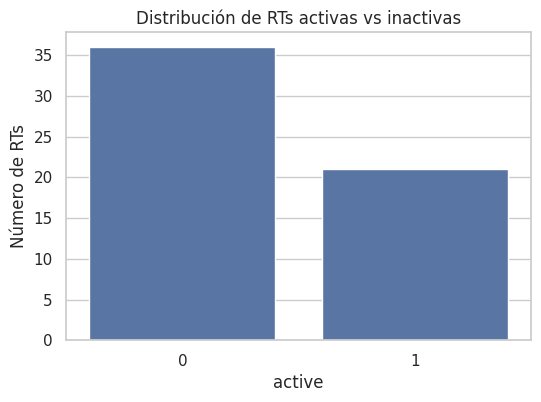

active
0    36
1    21
Name: count, dtype: int64
active
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train_df, x="active")
ax.set_title("Distribución de RTs activas vs inactivas")
ax.set_xlabel("active")
ax.set_ylabel("Número de RTs")
plt.show()

print(train_df["active"].value_counts(dropna=False))
print(train_df["active"].value_counts(normalize=True, dropna=False))

# 9) Distribución del target continuo: pe_efficiency_pct

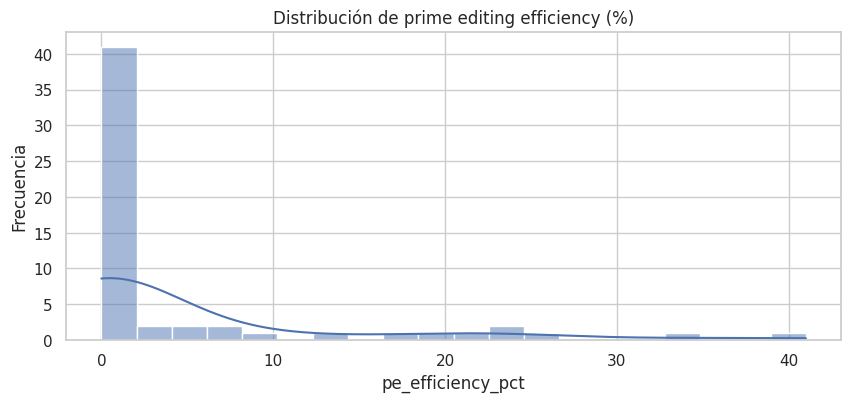

count    57.000000
mean      4.614035
std       9.362262
min       0.000000
25%       0.000000
50%       0.000000
75%       3.500000
max      41.000000
Name: pe_efficiency_pct, dtype: float64

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(train_df["pe_efficiency_pct"], bins=20, kde=True)
plt.title("Distribución de prime editing efficiency (%)")
plt.xlabel("pe_efficiency_pct")
plt.ylabel("Frecuencia")
plt.show()

display(train_df["pe_efficiency_pct"].describe())

# 10) Relación entre active y pe_efficiency_pct

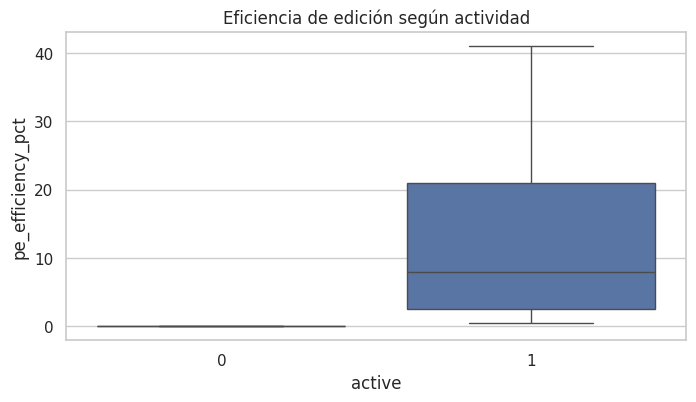

,count,mean,std,min,25%,50%,75%,max
active,,,,,,,,
0,36.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0
1,21.0,12.52381,11.891674,0.5,2.5,8.0,21.0,41.0


In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_df, x="active", y="pe_efficiency_pct")
plt.title("Eficiencia de edición según actividad")
plt.xlabel("active")
plt.ylabel("pe_efficiency_pct")
plt.show()

display(
    train_df.groupby("active")["pe_efficiency_pct"].describe()
)

# 11) Composición por familia evolutiva

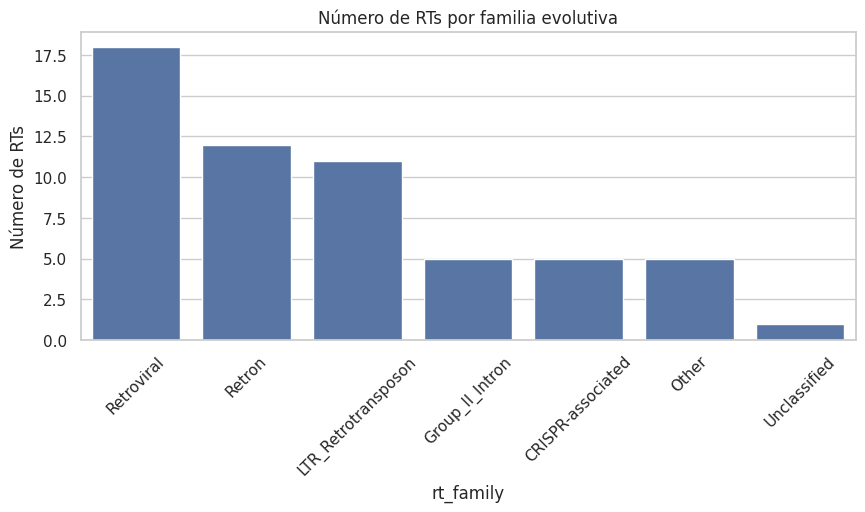

rt_family
Retroviral             18
Retron                 12
LTR_Retrotransposon    11
Group_II_Intron         5
CRISPR-associated       5
Other                   5
Unclassified            1
Name: count, dtype: int64

In [11]:
family_counts = train_df["rt_family"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.countplot(data=train_df, x="rt_family", order=family_counts.index)
plt.title("Número de RTs por familia evolutiva")
plt.xlabel("rt_family")
plt.ylabel("Número de RTs")
plt.xticks(rotation=45)
plt.show()

display(train_df["rt_family"].value_counts())

# 12) Actividad por familia: conteos y proporciones

,n_samples,n_active,active_rate,n_inactive
rt_family,,,,
Retroviral,18,12,0.666667,6
Retron,12,5,0.416667,7
LTR_Retrotransposon,11,2,0.181818,9
Group_II_Intron,5,2,0.400000,3
CRISPR-associated,5,0,0.000000,5
Other,5,0,0.000000,5
Unclassified,1,0,0.000000,1


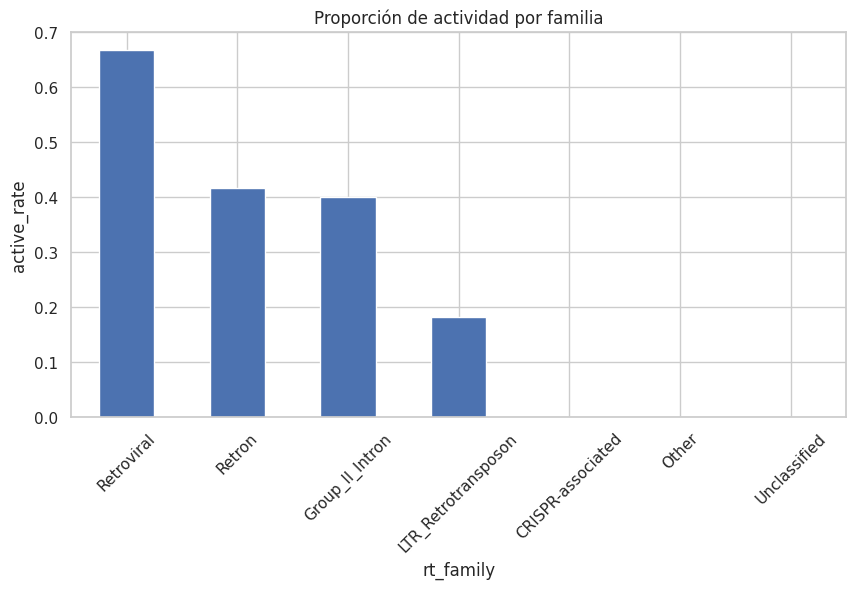

In [12]:
family_activity = (
    train_df.groupby("rt_family")["active"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_samples", "sum": "n_active", "mean": "active_rate"})
    .sort_values("n_samples", ascending=False)
)

family_activity["n_inactive"] = family_activity["n_samples"] - family_activity["n_active"]
display(family_activity)

plt.figure(figsize=(10, 5))
family_activity["active_rate"].sort_values(ascending=False).plot(kind="bar")
plt.title("Proporción de actividad por familia")
plt.xlabel("rt_family")
plt.ylabel("active_rate")
plt.xticks(rotation=45)
plt.show()

# 13) Cruce con family_splits.csv

In [13]:
print("family_splits.csv")
display(family_df)

# Si los nombres de columnas no coinciden exactamente, ajustarlos según el archivo real.

family_splits.csv


,family,n_samples,n_active,n_inactive,rt_names
0,CRISPR-associated,5,0,5,A.platensis-Cas1-RT|CRISPRRT2-RT|FuRT-Cas1-RT|...
1,Group_II_Intron,5,2,3,Er-RT|GroupII_CLA-RT|Gs-RT|LtrA-RT|Tel4c-RT
2,LTR_Retrotransposon,11,2,9,Bel-RT|CHLRE|FoxC-RT|Gate-RT|Gypsy-RT|Line1-RT...
3,Other,5,0,5,Abi-RT|CaMV-RT|DRG2-RT|Drg-RT|TCDM_11122-RT
4,Retron,12,5,7,Ec48-RT|Ec67-RT|Mx65-RT|Ne144-RT|Retron86-RT|R...
5,Retroviral,18,12,6,ASLV-RT|AVIRE-RT|BAEMV-RT|BLV-RT|FENV1-RT|GALV...
6,Unclassified,1,0,1,AFY36037.1-RT


# 14) Longitud proteica: distribución global y por familia

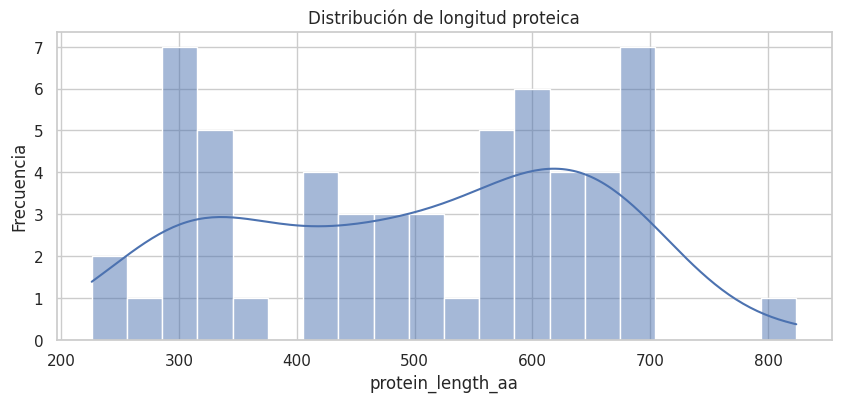

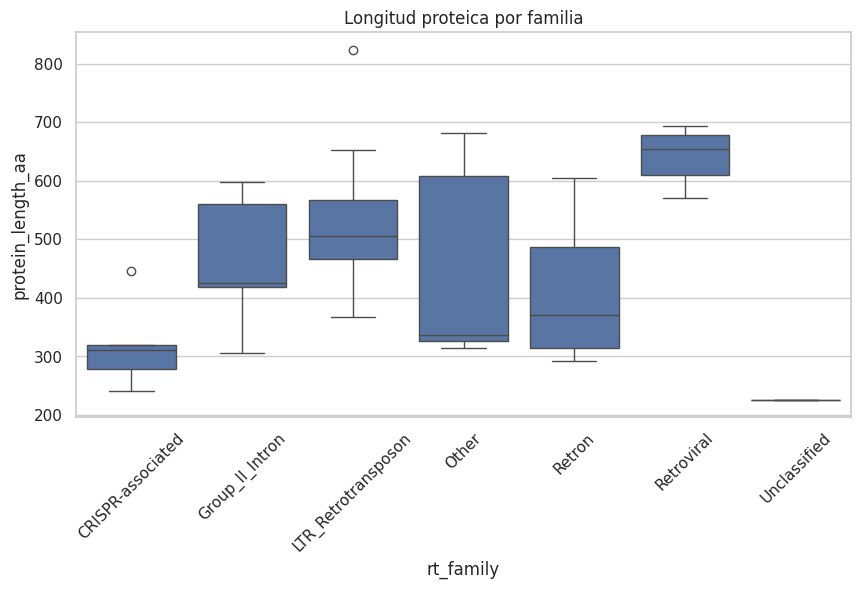

,count,mean,std,min,25%,50%,75%,max
rt_family,,,,,,,,
Retroviral,18.0,641.222222,43.782290,571.0,609.25,654.0,677.75,693.0
LTR_Retrotransposon,11.0,534.090909,122.633971,367.0,466.50,505.0,566.50,824.0
Group_II_Intron,5.0,462.000000,118.086832,306.0,419.00,426.0,561.00,598.0
Other,5.0,453.600000,176.828448,315.0,327.00,336.0,608.00,682.0
Retron,12.0,407.916667,113.277181,292.0,313.50,370.0,487.50,604.0
CRISPR-associated,5.0,318.800000,77.644704,240.0,278.00,311.0,319.00,446.0
Unclassified,1.0,226.000000,NaN,226.0,226.00,226.0,226.00,226.0


In [14]:
plt.figure(figsize=(10, 4))
sns.histplot(train_df["protein_length_aa"], bins=20, kde=True)
plt.title("Distribución de longitud proteica")
plt.xlabel("protein_length_aa")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df, x="rt_family", y="protein_length_aa")
plt.title("Longitud proteica por familia")
plt.xlabel("rt_family")
plt.ylabel("protein_length_aa")
plt.xticks(rotation=45)
plt.show()

display(
    train_df.groupby("rt_family")["protein_length_aa"].describe().sort_values("mean", ascending=False)
)

# 15) Longitud proteica según actividad

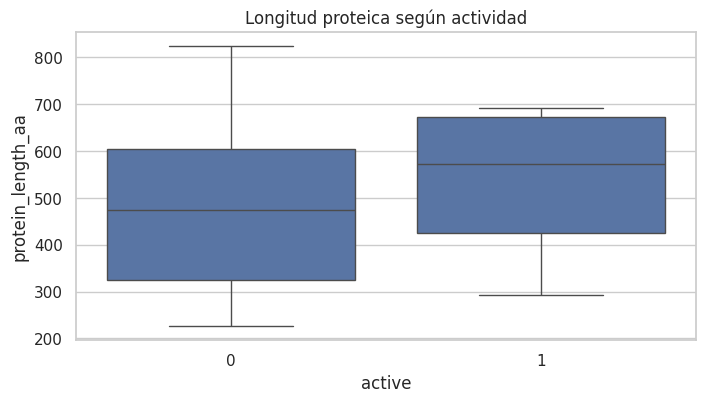

,count,mean,std,min,25%,50%,75%,max
active,,,,,,,,
0,36.0,479.472222,153.451991,226.0,325.0,474.0,604.75,824.0
1,21.0,545.190476,137.409104,292.0,426.0,572.0,672.00,693.0


In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_df, x="active", y="protein_length_aa")
plt.title("Longitud proteica según actividad")
plt.xlabel("active")
plt.ylabel("protein_length_aa")
plt.show()

display(
    train_df.groupby("active")["protein_length_aa"].describe()
)

# 16) Missing values: visión global

,column,missing_count,missing_pct
69,connection_mean_pot,33,57.894737
66,yxdd_5A_mean_pot,7,12.280702
51,yxdd_std_hydrophobicity,7,12.280702
19,D1_D2_dist,7,12.280702
20,D2_D3_dist,7,12.280702
21,triad_best_rmsd,7,12.280702
30,yxdd_mean_hydrophobicity,7,12.280702
29,yxdd_hydrophobic_fraction,7,12.280702
61,yxdd_seq,4,7.017544
60,hairpin_confidence,4,7.017544


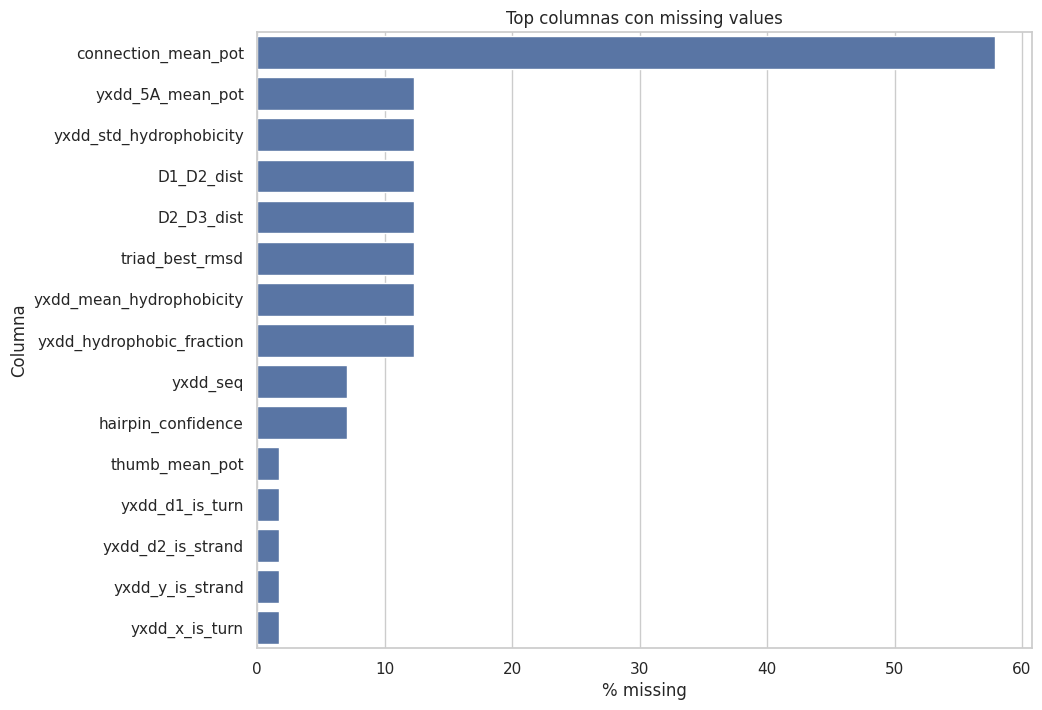

In [16]:
missing_df = pd.DataFrame({
    "column": train_df.columns,
    "missing_count": train_df.isna().sum().values,
    "missing_pct": (train_df.isna().mean().values * 100)
}).sort_values("missing_pct", ascending=False)

display(missing_df.head(30))

plt.figure(figsize=(10, 8))
top_missing = missing_df[missing_df["missing_count"] > 0].head(25)
sns.barplot(data=top_missing, x="missing_pct", y="column")
plt.title("Top columnas con missing values")
plt.xlabel("% missing")
plt.ylabel("Columna")
plt.show()

# 17) Missing por familia

In [18]:
# ============================================================
# Missing por familia
# ============================================================
# Aquí analizamos missing values por familia evolutiva SOLO en
# features numéricas, porque son las que luego usaríamos en modelado.
# Esto nos permite ver si ciertos NaNs están concentrados en una
# familia específica, lo cual puede reflejar diferencias biológicas
# reales o sesgo por linaje.
# ============================================================

# Missing global solo para features numéricas
missing_feature_df = pd.DataFrame({
    "column": feature_cols,
    "missing_count": train_df[feature_cols].isna().sum().values,
    "missing_pct": train_df[feature_cols].isna().mean().values * 100
}).sort_values("missing_pct", ascending=False)

# Missing por familia
missing_by_family = (
    train_df.groupby("rt_family")[feature_cols]
    .apply(lambda x: x.isna().mean())
)

# Top columnas numéricas con missing
top_missing_feature_cols = (
    missing_feature_df[missing_feature_df["missing_count"] > 0]["column"]
    .head(10)
    .tolist()
)

display(missing_by_family[top_missing_feature_cols].T)

rt_family,CRISPR-associated,Group_II_Intron,LTR_Retrotransposon,Other,Retron,Retroviral,Unclassified
connection_mean_pot,1.0,1.0,0.545455,0.8,1.000000,0.0,1.0
yxdd_mean_hydrophobicity,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
D2_D3_dist,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
yxdd_hydrophobic_fraction,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
D1_D2_dist,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
yxdd_std_hydrophobicity,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
yxdd_5A_mean_pot,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
triad_best_rmsd,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
hairpin_confidence,0.0,0.2,0.000000,0.0,0.166667,0.0,1.0
yxdd_d1_is_turn,0.0,0.0,0.090909,0.0,0.000000,0.0,0.0


# 18) Separar columnas numéricas, binarias y categóricas de interés

In [19]:
# Intento simple de columnas binarias numéricas
binary_like_cols = []
continuous_like_cols = []

for col in feature_cols:
    vals = train_df[col].dropna().unique()
    if len(vals) <= 2 and set(vals).issubset({0, 1}):
        binary_like_cols.append(col)
    else:
        continuous_like_cols.append(col)

print("Columnas binarias tipo flag:", len(binary_like_cols))
print(binary_like_cols)

print("\nColumnas continuas:", len(continuous_like_cols))
print(continuous_like_cols[:25], "...")

Columnas binarias tipo flag: 6
['triad_found_bin', 'hairpin_pass', 'yxdd_y_is_strand', 'yxdd_x_is_turn', 'yxdd_d1_is_turn', 'yxdd_d2_is_strand']

Columnas continuas: 59
['protein_length_aa', 'perplexity', 'instability_index', 'gravy', 't40_raw', 't45_raw', 't50_raw', 't55_raw', 't60_raw', 't65_raw', 't70_raw', 't75_raw', 't80_raw', 'thermophilicity_num', 'D1_D2_dist', 'D2_D3_dist', 'triad_best_rmsd', 'hydrophobic_per_res', 'salt_per_res', 'hbonds_per_res', 'pocket_hydrophobic_per_res', 'pocket_hbonds_per_res', 'whole_mean_hydrophobicity', 'whole_std_hydrophobicity', 'yxdd_hydrophobic_fraction'] ...


# 19) Resumen estadístico de features numéricas

In [20]:
numeric_summary = train_df[feature_cols].describe().T
numeric_summary["missing_count"] = train_df[feature_cols].isna().sum()
numeric_summary["missing_pct"] = train_df[feature_cols].isna().mean() * 100

display(numeric_summary.sort_values("missing_pct", ascending=False).head(30))
display(numeric_summary.sort_values("std", ascending=False).head(30))

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
connection_mean_pot,24.0,4.411679,3.449262,-2.028800e+00,2.489700,4.504050,6.595975,9.273300,33,57.894737
yxdd_mean_hydrophobicity,50.0,1.010668,0.501038,-5.900000e-03,0.697950,1.095000,1.267775,2.038900,7,12.280702
D2_D3_dist,50.0,3.826244,0.027400,3.763500e+00,3.810575,3.827400,3.843625,3.891500,7,12.280702
yxdd_hydrophobic_fraction,50.0,0.579502,0.096590,3.529000e-01,0.529400,0.600000,0.662525,0.736800,7,12.280702
D1_D2_dist,50.0,10.812502,8.421315,5.475400e+00,6.038875,6.847050,11.674475,44.434800,7,12.280702
yxdd_std_hydrophobicity,50.0,2.924396,0.201700,2.492700e+00,2.803325,2.948950,3.053400,3.478200,7,12.280702
yxdd_5A_mean_pot,50.0,-5.806686,7.619817,-1.822280e+01,-11.234875,-6.116350,-0.825850,9.775500,7,12.280702
triad_best_rmsd,50.0,4.713292,6.576996,1.275000e-01,0.212400,0.823650,7.351400,27.148700,7,12.280702
hairpin_confidence,53.0,0.738811,0.067557,4.840000e-01,0.699000,0.750000,0.770000,0.850000,4,7.017544
yxdd_d1_is_turn,56.0,0.875000,0.333712,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1,1.754386


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
protein_length_aa,57.0,503.684211,149.944651,226.000000,336.000000,523.000000,626.000000,824.000000,0,0.000000
seq_length,57.0,503.684211,149.944651,226.000000,336.000000,523.000000,626.000000,824.000000,0,0.000000
n_residues,57.0,503.807018,149.876906,226.000000,336.000000,523.000000,626.000000,824.000000,0,0.000000
nterm_avg_sasa,57.0,127.255614,13.503125,97.970000,117.610000,125.930000,137.240000,153.770000,0,0.000000
net_charge,57.0,15.157895,13.360108,-11.000000,5.000000,13.000000,24.000000,49.000000,0,0.000000
D1_D2_dist,50.0,10.812502,8.421315,5.475400,6.038875,6.847050,11.674475,44.434800,7,12.280702
thumb_mean_pot,56.0,9.320611,7.789290,-13.131700,4.537125,10.424750,13.739800,23.807000,1,1.754386
motif12_mean_pot,57.0,13.458623,7.750604,-6.237400,10.414100,13.785400,16.423800,33.530800,0,0.000000
yxdd_5A_mean_pot,50.0,-5.806686,7.619817,-18.222800,-11.234875,-6.116350,-0.825850,9.775500,7,12.280702
lpqg_sp_3A_mean_pot,57.0,9.963796,7.564308,-12.495300,5.531300,10.529900,14.147900,26.273900,0,0.000000


# 20) Relación entre features y actividad: screening univariado simple

In [21]:
# Diferencia de medias entre activas e inactivas para variables continuas
univariate_rows = []

for col in continuous_like_cols:
    grp0 = train_df.loc[train_df["active"] == 0, col].dropna()
    grp1 = train_df.loc[train_df["active"] == 1, col].dropna()
    
    if len(grp0) > 1 and len(grp1) > 1:
        row = {
            "feature": col,
            "mean_inactive": grp0.mean(),
            "mean_active": grp1.mean(),
            "diff_active_minus_inactive": grp1.mean() - grp0.mean(),
            "median_inactive": grp0.median(),
            "median_active": grp1.median(),
            "missing_pct": train_df[col].isna().mean() * 100
        }
        univariate_rows.append(row)

univariate_df = pd.DataFrame(univariate_rows)
univariate_df = univariate_df.sort_values("diff_active_minus_inactive", ascending=False)

display(univariate_df.head(20))
display(univariate_df.tail(20))

,feature,mean_inactive,mean_active,diff_active_minus_inactive,median_inactive,median_active,missing_pct
42,n_residues,479.472222,545.523810,66.051587,474.000000,572.000000,0.000000
36,seq_length,479.472222,545.190476,65.718254,474.000000,572.000000,0.000000
0,protein_length_aa,479.472222,545.190476,65.718254,474.000000,572.000000,0.000000
47,nterm_avg_sasa,125.744444,129.846190,4.101746,122.170000,134.110000,0.000000
48,rama_fav,89.377778,91.095238,1.717460,90.650000,91.700000,0.000000
57,thumb_mean_pot,8.848506,10.107452,1.258947,8.509200,11.548500,1.754386
58,connection_mean_pot,3.820470,4.833971,1.013501,3.891400,4.660550,57.894737
37,log_likelihood,-1.854234,-1.542475,0.311759,-1.918737,-1.525853,0.000000
28,foldseek_best_fident,0.270806,0.504762,0.233956,0.231500,0.457000,0.000000
10,t70_raw,0.379568,0.532083,0.152515,0.202850,0.662900,0.000000


,feature,mean_inactive,mean_active,diff_active_minus_inactive,median_inactive,median_active,missing_pct
23,whole_std_hydrophobicity,3.124722,3.105833,-0.018889,3.125500,3.071400,0.000000
5,t45_raw,0.475090,0.441270,-0.033820,0.497850,0.470800,0.000000
35,foldseek_TM_Telomerase,0.632458,0.587619,-0.044839,0.602600,0.561700,0.000000
34,foldseek_TM_Group2Intron,0.762942,0.716452,-0.046489,0.785700,0.658800,0.000000
19,hbonds_per_res,1.490083,1.443000,-0.047083,1.517000,1.353000,0.000000
39,camsol,0.414306,0.357426,-0.056879,0.575911,0.532101,0.000000
4,t40_raw,0.488463,0.420951,-0.067511,0.547950,0.401500,0.000000
49,rama_out,0.825000,0.509524,-0.315476,0.400000,0.500000,0.000000
2,instability_index,42.739756,42.149430,-0.590326,43.576839,41.867098,0.000000
51,overall_mean_pot,6.574150,5.709576,-0.864574,6.112000,5.419700,0.000000


# 21) Visualizar algunas features prometedoras o interesantes

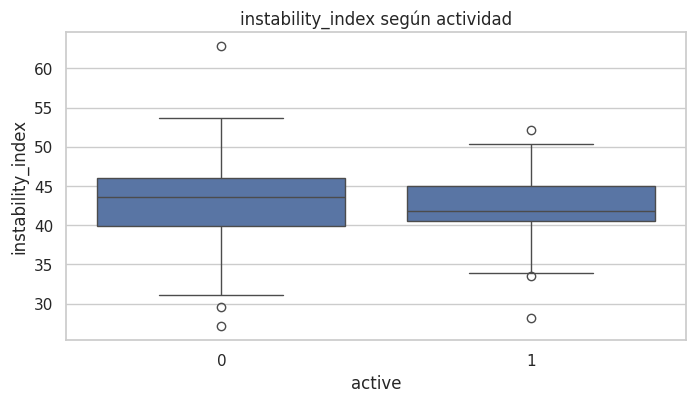

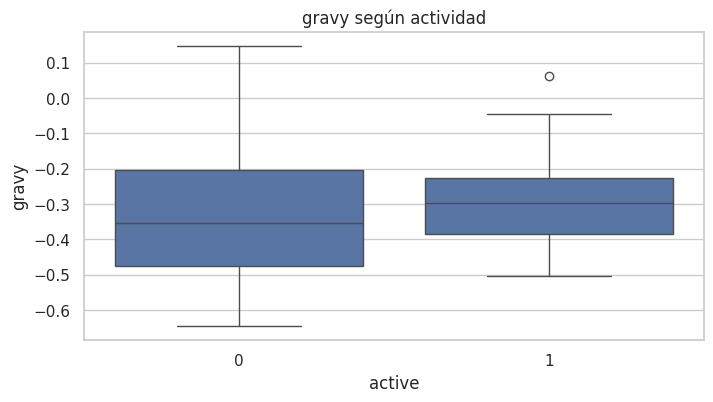

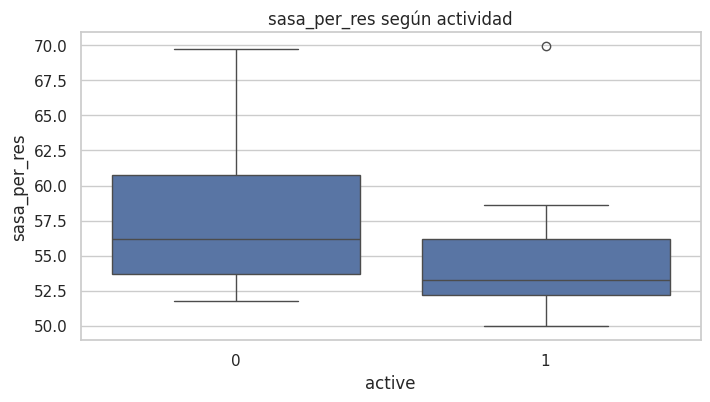

In [22]:
# Ajusta esta lista después de ver el diccionario y el summary real
candidate_features_to_plot = [
    "instability_index",
    "gravy",
    "net_charge_pH7",
    "camsol_intrinsic",
    "triad_rmsd_to_hiv",
    "sasa_per_res",
]

candidate_features_to_plot = [c for c in candidate_features_to_plot if c in train_df.columns]

for col in candidate_features_to_plot:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=train_df, x="active", y=col)
    plt.title(f"{col} según actividad")
    plt.xlabel("active")
    plt.ylabel(col)
    plt.show()

# 22) Proporción de actividad en features binarias

In [23]:
binary_activity_rows = []

for col in binary_like_cols:
    tab = pd.crosstab(train_df[col], train_df["active"], normalize="index")
    if 1 in tab.columns:
        active_rate_when_present = tab.loc[1, 1] if 1 in tab.index else np.nan
        active_rate_when_absent = tab.loc[0, 1] if 0 in tab.index else np.nan
    else:
        active_rate_when_present = np.nan
        active_rate_when_absent = np.nan
    
    binary_activity_rows.append({
        "feature": col,
        "active_rate_when_0": active_rate_when_absent,
        "active_rate_when_1": active_rate_when_present,
        "diff": (active_rate_when_present - active_rate_when_absent) if pd.notna(active_rate_when_present) and pd.notna(active_rate_when_absent) else np.nan
    })

binary_activity_df = pd.DataFrame(binary_activity_rows).sort_values("diff", ascending=False)
display(binary_activity_df)

,feature,active_rate_when_0,active_rate_when_1,diff
1,hairpin_pass,0.000000,0.396226,0.396226
2,yxdd_y_is_strand,0.125000,0.416667,0.291667
4,yxdd_d1_is_turn,0.142857,0.408163,0.265306
3,yxdd_x_is_turn,0.142857,0.408163,0.265306
5,yxdd_d2_is_strand,0.142857,0.408163,0.265306
0,triad_found_bin,0.142857,0.400000,0.257143


# 23) Correlación entre features numéricas


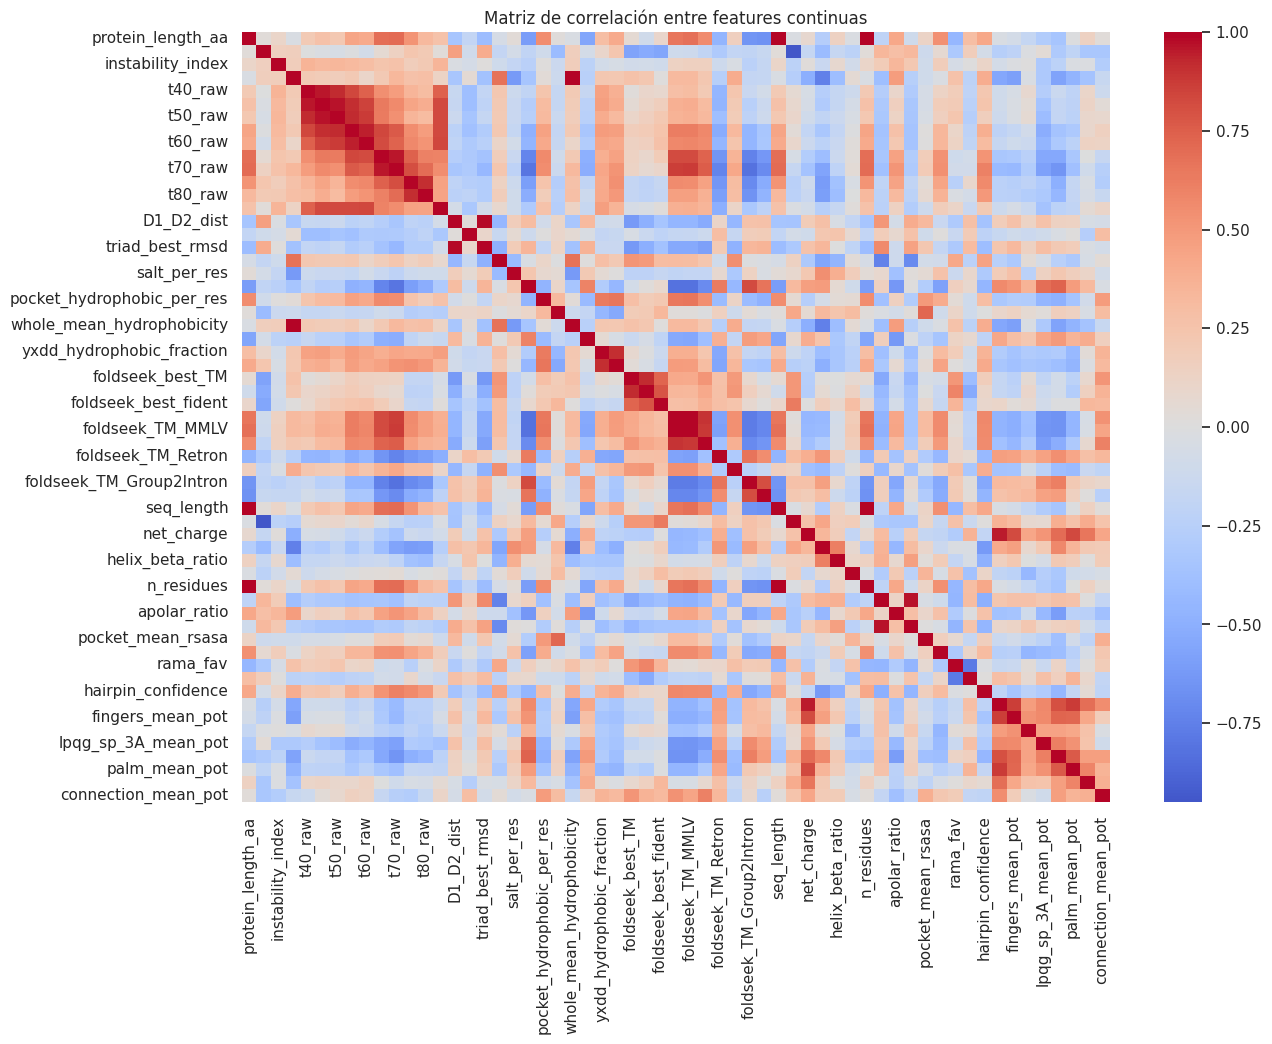

In [24]:
corr = train_df[continuous_like_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre features continuas")
plt.show()

# 24) Pares de features muy correlacionadas

In [25]:
# Extraer pares altamente correlacionados
corr_pairs = corr.abs().unstack().reset_index()
corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]

corr_pairs = corr_pairs[corr_pairs["feature_1"] < corr_pairs["feature_2"]]
corr_pairs = corr_pairs.sort_values("abs_corr", ascending=False)

display(corr_pairs.head(30))

,feature_1,feature_2,abs_corr
36,protein_length_aa,seq_length,1.000000
199,gravy,whole_mean_hydrophobicity,1.000000
2478,n_residues,protein_length_aa,0.999981
2514,n_residues,seq_length,0.999981
1741,foldseek_TM_HIV1,foldseek_TM_MMLV,0.996433
842,D1_D2_dist,triad_best_rmsd,0.979648
301,t45_raw,t50_raw,0.969520
2698,mean_rsasa,sasa_per_res,0.962737
541,t65_raw,t70_raw,0.959088
241,t40_raw,t45_raw,0.957564


# 25) Correlación con pe_efficiency_pct

In [26]:
corr_with_eff = (
    train_df[feature_cols + ["pe_efficiency_pct"]]
    .corr()["pe_efficiency_pct"]
    .drop("pe_efficiency_pct")
    .sort_values(ascending=False)
)

display(corr_with_eff.head(20))
display(corr_with_eff.tail(20))

foldseek_TM_MMLV                  0.528167
foldseek_TM_HIV1                  0.523673
foldseek_TM_MMLVPE                0.522287
foldseek_best_fident              0.482346
pocket_hydrophobic_per_res        0.474885
foldseek_best_TM                  0.431640
t65_raw                           0.410179
foldseek_best_LDDT                0.386545
t70_raw                           0.367395
t55_raw                           0.355210
protein_length_aa                 0.349907
seq_length                        0.349907
n_residues                        0.349743
t60_raw                           0.306434
nterm_avg_sasa                    0.280558
foldseek_TM_LTRRetrotransposon    0.255637
log_likelihood                    0.254523
yxdd_std_hydrophobicity           0.238587
yxdd_mean_hydrophobicity          0.198826
yxdd_y_is_strand                  0.197051
Name: pe_efficiency_pct, dtype: float64

gravy                      -0.023160
foldseek_TM_Retron         -0.082454
D2_D3_dist                 -0.092699
overall_mean_pot           -0.168664
motif12_mean_pot           -0.175122
rama_out                   -0.179376
fingers_mean_pot           -0.190509
net_charge                 -0.191737
palm_mean_pot              -0.243506
yxdd_5A_mean_pot           -0.247084
mean_rsasa                 -0.254726
D1_D2_dist                 -0.261402
perplexity                 -0.267241
whole_std_hydrophobicity   -0.279830
foldseek_TM_Group2Intron   -0.286530
hbonds_per_res             -0.289015
sasa_per_res               -0.309742
triad_best_rmsd            -0.317996
foldseek_TM_Telomerase     -0.355596
lpqg_sp_3A_mean_pot        -0.427479
Name: pe_efficiency_pct, dtype: float64

# 26) Importancia de familia: medias de features por rt_family

In [27]:
family_feature_means = train_df.groupby("rt_family")[continuous_like_cols].mean().T

# Mostrar una parte para inspección manual
display(family_feature_means.iloc[:20, :])

rt_family,CRISPR-associated,Group_II_Intron,LTR_Retrotransposon,Other,Retron,Retroviral,Unclassified
protein_length_aa,318.800000,462.000000,534.090909,453.600000,407.916667,641.222222,226.000000
perplexity,7.792422,2.789627,9.129964,7.316440,6.444898,6.117203,4.370306
instability_index,39.855526,40.474915,43.784464,40.255486,41.735053,44.032084,45.812389
gravy,-0.253239,-0.491500,-0.318177,-0.394820,-0.351490,-0.207002,-0.394248
t40_raw,0.395710,0.584860,0.544264,0.366842,0.230632,0.573272,0.614200
t45_raw,0.338132,0.558440,0.588209,0.324290,0.204617,0.598461,0.567600
t50_raw,0.308852,0.478940,0.505327,0.260512,0.187938,0.519061,0.495700
t55_raw,0.304853,0.423304,0.632573,0.284506,0.192751,0.691539,0.492100
t60_raw,0.230569,0.320396,0.500409,0.203618,0.140595,0.493528,0.363000
t65_raw,0.092260,0.154673,0.594045,0.243902,0.128948,0.752156,0.256100


# 27) Features que más varían entre familias

In [28]:
family_variation_rows = []

for col in continuous_like_cols:
    means_by_family = train_df.groupby("rt_family")[col].mean()
    family_variation_rows.append({
        "feature": col,
        "std_of_family_means": means_by_family.std(),
        "max_family_mean": means_by_family.max(),
        "min_family_mean": means_by_family.min(),
        "range_family_mean": means_by_family.max() - means_by_family.min(),
        "missing_pct": train_df[col].isna().mean() * 100
    })

family_variation_df = pd.DataFrame(family_variation_rows).sort_values("range_family_mean", ascending=False)

display(family_variation_df.head(30))

,feature,std_of_family_means,max_family_mean,min_family_mean,range_family_mean,missing_pct
0,protein_length_aa,136.221787,641.222222,226.000000,415.222222,0.000000
36,seq_length,136.221787,641.222222,226.000000,415.222222,0.000000
42,n_residues,136.269390,641.222222,226.000000,415.222222,0.000000
38,net_charge,11.030041,31.800000,-0.800000,32.600000,0.000000
14,D1_D2_dist,6.821117,26.936100,6.082017,20.854083,12.280702
47,nterm_avg_sasa,7.159782,135.103333,116.168000,18.935333,0.000000
16,triad_best_rmsd,5.664723,18.121300,0.239183,17.882117,12.280702
57,thumb_mean_pot,5.141942,16.711400,0.899875,15.811525,1.754386
43,sasa_per_res,5.033500,68.830089,53.429100,15.400989,0.000000
55,yxdd_5A_mean_pot,5.553849,3.145000,-12.042350,15.187350,12.280702


# 28) Visualización puntual de features con posible sesgo de familia

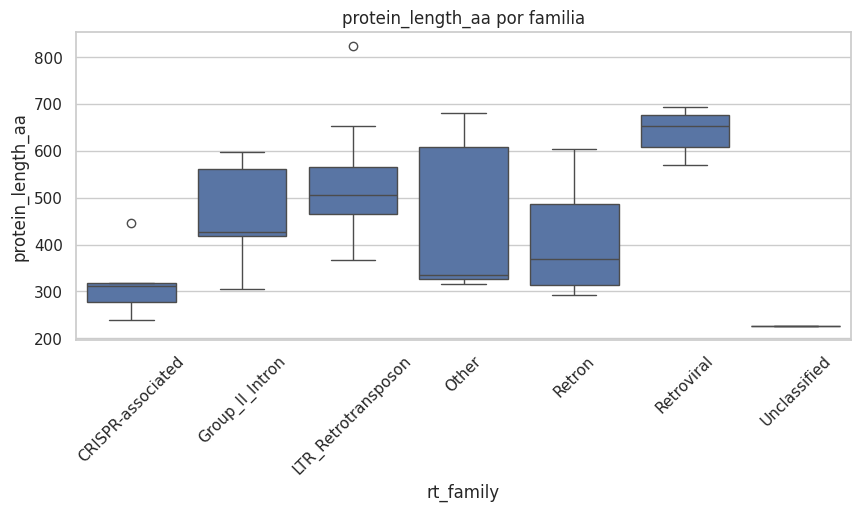

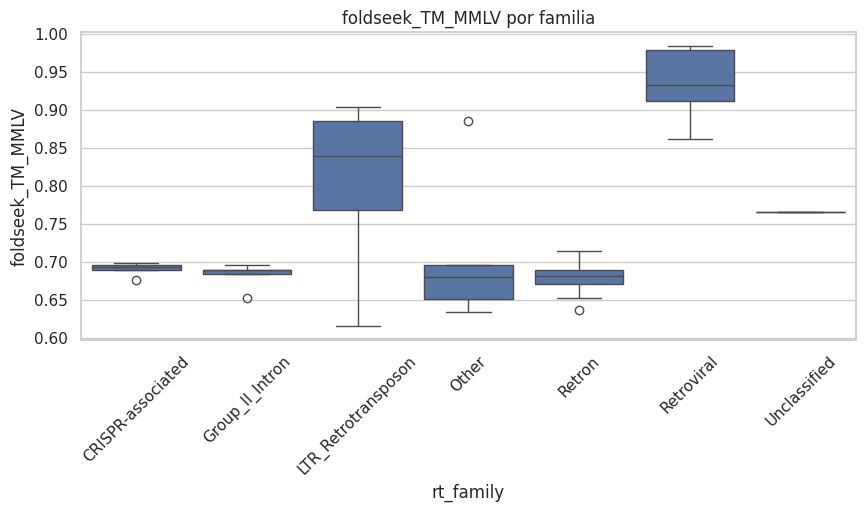

In [29]:
features_family_bias_plot = [
    "protein_length_aa",
    "resolved_residues",
    "foldseek_TM_MMLV",
    "foldseek_TM_HIV",
]

features_family_bias_plot = [c for c in features_family_bias_plot if c in train_df.columns]

for col in features_family_bias_plot:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=train_df, x="rt_family", y=col)
    plt.title(f"{col} por familia")
    plt.xlabel("rt_family")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()

# 29) Revisar el diccionario de features

In [30]:
print("Columnas de feature_dictionary.csv:")
print(feat_dict_df.columns.tolist())

display(feat_dict_df.head(20))

Columnas de feature_dictionary.csv:
['feature', 'description']


,feature,description
0,perplexity,"ESM-IF inverse folding perplexity — how ""surpr..."
1,instability_index,Guruprasad instability index. >40 = predicted ...
2,gravy,Grand Average of Hydropathy (Kyte-Doolittle). ...
3,t40_raw,Predicted fraction of residues retaining struc...
4,t45_raw,Predicted fraction retaining structure at 45C.
5,t50_raw,Predicted fraction retaining structure at 50C.
6,t55_raw,Predicted fraction retaining structure at 55C.
7,t60_raw,Predicted fraction retaining structure at 60C.
8,t65_raw,Predicted fraction retaining structure at 65C.
9,t70_raw,Predicted fraction retaining structure at 70C.


# 30) Intento de mapear categorías biológicas de features

In [31]:
# Ajusta nombres de columnas según el archivo real
feat_dict_df.columns = [c.strip().lower() for c in feat_dict_df.columns]

display(feat_dict_df.head())

# Ejemplo: si existen columnas 'feature' y 'group'
if "feature" in feat_dict_df.columns and "group" in feat_dict_df.columns:
    group_counts = feat_dict_df["group"].value_counts()
    display(group_counts)

    plt.figure(figsize=(10, 5))
    group_counts.plot(kind="bar")
    plt.title("Número de features por grupo biológico")
    plt.xlabel("Grupo")
    plt.ylabel("Número de features")
    plt.xticks(rotation=45)
    plt.show()

,feature,description
0,perplexity,"ESM-IF inverse folding perplexity — how ""surpr..."
1,instability_index,Guruprasad instability index. >40 = predicted ...
2,gravy,Grand Average of Hydropathy (Kyte-Doolittle). ...
3,t40_raw,Predicted fraction of residues retaining struc...
4,t45_raw,Predicted fraction retaining structure at 45C.


# 31) Tabla resumen final del EDA inicial

In [32]:
eda_summary = {
    "n_samples": len(train_df),
    "n_families": train_df["rt_family"].nunique(),
    "n_active": int(train_df["active"].sum()),
    "n_inactive": int((train_df["active"] == 0).sum()),
    "active_rate": float(train_df["active"].mean()),
    "n_numeric_features": len(feature_cols),
    "n_binary_like_features": len(binary_like_cols),
    "n_continuous_like_features": len(continuous_like_cols),
    "n_columns_with_missing": int((train_df.isna().sum() > 0).sum()),
}

eda_summary_df = pd.DataFrame([eda_summary])
display(eda_summary_df)

,n_samples,n_families,n_active,n_inactive,active_rate,n_numeric_features,n_binary_like_features,n_continuous_like_features,n_columns_with_missing
0,57,7,21,36,0.368421,65,6,59,15


# EDA por Bloques Biologicos

In [33]:
# ============================================================
# SEGUNDA ETAPA DEL EDA - ANALISIS POR BLOQUES BIOLOGICOS
# ============================================================
# Objetivo:
# Explorar las features agrupadas en bloques funcionales para entender
# si la señal predictiva parece venir de:
# 1) arquitectura catalítica
# 2) propiedades fisicoquímicas globales
# 3) electrostática local
# 4) estabilidad / termoestabilidad
# 5) similitud estructural (FoldSeek)
# 6) metadata global
#
# Esto es importante porque en esta competencia queremos separar:
# - señales de FUNCIÓN
# - señales de LINAJE / familia evolutiva
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ------------------------------------------------------------
# 1. Definir bloques biológicos automáticamente por nombre
# ------------------------------------------------------------
# Nota bioinformática:
# Aquí agrupamos features por patrones en el nombre. Esto no es perfecto,
# pero funciona bien como primera taxonomía funcional del dataset.


all_cols = train_df.columns.tolist()

block_dict = {
    "metadata_global": [
        c for c in all_cols
        if c in ["protein_length_aa", "seq_length", "n_residues", "resolved_residues"]
    ],
    
    "catalitico_triada_yxdd_hairpin": [
        c for c in all_cols
        if (
            ("triad" in c.lower()) or
            ("yxdd" in c.lower()) or
            ("hairpin" in c.lower()) or
            (c in ["D1_D2_dist", "D2_D3_dist"])
        )
    ],
    
    "hidrofobicidad_y_superficie": [
        c for c in all_cols
        if (
            ("hydrophobic" in c.lower()) or
            ("gravy" in c.lower()) or
            ("sasa" in c.lower()) or
            ("rsasa" in c.lower()) or
            ("hbonds" in c.lower()) or
            ("pocket_" in c.lower())
        )
    ],
    
    "electrostatica_local": [
        c for c in all_cols
        if (
            ("mean_pot" in c.lower()) or
            ("overall_mean_pot" in c.lower()) or
            ("palm_mean_pot" in c.lower()) or
            ("fingers_mean_pot" in c.lower()) or
            ("thumb_mean_pot" in c.lower()) or
            ("motif12_mean_pot" in c.lower()) or
            ("lpqg_sp_3a_mean_pot" in c.lower()) or
            ("net_charge" in c.lower())
        )
    ],
    
    "estabilidad_termo": [
        c for c in all_cols
        if (
            ("t40" in c.lower()) or
            ("t45" in c.lower()) or
            ("t50" in c.lower()) or
            ("t55" in c.lower()) or
            ("t60" in c.lower()) or
            ("t65" in c.lower()) or
            ("t70" in c.lower()) or
            ("t75" in c.lower()) or
            ("t80" in c.lower()) or
            ("thermo" in c.lower()) or
            ("instability" in c.lower()) or
            ("camsol" in c.lower())
        )
    ],
    
    "similitud_estructural_foldseek": [
        c for c in all_cols
        if ("foldseek" in c.lower())
    ],
    
    "modelo_secuencia_global": [
        c for c in all_cols
        if (
            ("log_likelihood" in c.lower()) or
            ("perplexity" in c.lower())
        )
    ],
}

# Eliminar columnas duplicadas dentro de cada bloque
for block_name in block_dict:
    block_dict[block_name] = sorted(list(set(block_dict[block_name])))

print("Resumen de bloques biológicos:")
for block_name, cols in block_dict.items():
    print(f"{block_name}: {len(cols)} columnas")
    print(cols[:10], "..." if len(cols) > 10 else "")
    print("-" * 80)

Resumen de bloques biológicos:
metadata_global: 3 columnas
['n_residues', 'protein_length_aa', 'seq_length'] 
--------------------------------------------------------------------------------
catalitico_triada_yxdd_hairpin: 15 columnas
['D1_D2_dist', 'D2_D3_dist', 'hairpin_confidence', 'hairpin_pass', 'triad_best_rmsd', 'triad_found_bin', 'yxdd_5A_mean_pot', 'yxdd_d1_is_turn', 'yxdd_d2_is_strand', 'yxdd_hydrophobic_fraction'] ...
--------------------------------------------------------------------------------
hidrofobicidad_y_superficie: 14 columnas
['gravy', 'hbonds_per_res', 'hydrophobic_per_res', 'mean_rsasa', 'nterm_avg_sasa', 'pocket_hbonds_per_res', 'pocket_hydrophobic_per_res', 'pocket_mean_rsasa', 'sasa_per_res', 'whole_mean_hydrophobicity'] ...
--------------------------------------------------------------------------------
electrostatica_local: 9 columnas
['connection_mean_pot', 'fingers_mean_pot', 'lpqg_sp_3A_mean_pot', 'motif12_mean_pot', 'net_charge', 'overall_mean_pot', 'p

## 3) Verificar si alguna columna quedó sin asignar

In [34]:
# ------------------------------------------------------------
# 2. Revisar columnas no asignadas a ningún bloque
# ------------------------------------------------------------
assigned_cols = set()
for cols in block_dict.values():
    assigned_cols.update(cols)

# Excluir columnas de identidad / target / secuencia
exclude_cols = {
    "rt_name", "sequence", "rt_family", "active", "pe_efficiency_pct"
}

unassigned_cols = [c for c in all_cols if c not in assigned_cols and c not in exclude_cols]

print("Columnas no asignadas a ningún bloque:")
print(unassigned_cols)

Columnas no asignadas a ningún bloque:
['salt_per_res', 'helix_beta_ratio', 'apolar_ratio', 'rama_fav', 'rama_out']


## 4) Funciones auxiliares

In [35]:
# ------------------------------------------------------------
# 3. Funciones auxiliares para el EDA por bloques
# ------------------------------------------------------------

def get_numeric_block_cols(df, cols):
    """Devuelve solo columnas numéricas dentro de un bloque."""
    return [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]


def summarize_block(df, block_name, cols):
    """
    Resume el bloque:
    - número de columnas
    - missing promedio
    - correlación máxima con eficiencia
    - correlación máxima con actividad
    """
    num_cols = get_numeric_block_cols(df, cols)
    
    if len(num_cols) == 0:
        return None
    
    rows = []
    for col in num_cols:
        # correlación con eficiencia
        corr_eff = df[[col, "pe_efficiency_pct"]].corr(method="spearman").iloc[0, 1]
        
        # correlación con active
        corr_act = df[[col, "active"]].corr(method="spearman").iloc[0, 1]
        
        rows.append({
            "feature": col,
            "missing_pct": df[col].isna().mean() * 100,
            "spearman_with_efficiency": corr_eff,
            "spearman_with_active": corr_act,
        })
    
    summary = pd.DataFrame(rows)
    summary["abs_eff"] = summary["spearman_with_efficiency"].abs()
    summary["abs_act"] = summary["spearman_with_active"].abs()
    
    print(f"\n{'='*100}")
    print(f"Bloque: {block_name}")
    print(f"Número de columnas numéricas: {len(num_cols)}")
    print(f"{'='*100}")
    
    display(summary.sort_values("abs_eff", ascending=False).head(15))
    
    return summary


def plot_top_boxplots_by_activity(df, summary_df, block_name, top_n=6):
    """
    Muestra boxplots de las variables más asociadas a actividad dentro del bloque.
    """
    if summary_df is None or len(summary_df) == 0:
        return
    
    top_features = (
        summary_df.sort_values("abs_act", ascending=False)["feature"]
        .head(top_n)
        .tolist()
    )
    
    for col in top_features:
        plt.figure(figsize=(7, 4))
        sns.boxplot(data=df, x="active", y=col)
        plt.title(f"{block_name} | {col} según actividad")
        plt.xlabel("active")
        plt.ylabel(col)
        plt.show()


def plot_top_boxplots_by_family(df, summary_df, block_name, top_n=4):
    """
    Muestra boxplots de las variables más variables por familia dentro del bloque.
    """
    if summary_df is None or len(summary_df) == 0:
        return
    
    candidate_cols = summary_df["feature"].tolist()
    
    family_var_rows = []
    for col in candidate_cols:
        means = df.groupby("rt_family")[col].mean()
        family_var_rows.append({
            "feature": col,
            "range_family_mean": means.max() - means.min(),
            "std_family_mean": means.std()
        })
    
    family_var_df = pd.DataFrame(family_var_rows).sort_values("range_family_mean", ascending=False)
    display(family_var_df.head(10))
    
    top_features = family_var_df["feature"].head(top_n).tolist()
    
    for col in top_features:
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=df, x="rt_family", y=col)
        plt.title(f"{block_name} | {col} por familia")
        plt.xlabel("rt_family")
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.show()


def plot_block_correlation_heatmap(df, cols, block_name, max_cols=20):
    """
    Heatmap de correlación dentro del bloque.
    Si el bloque tiene demasiadas columnas, toma las primeras max_cols.
    """
    num_cols = get_numeric_block_cols(df, cols)
    
    if len(num_cols) < 2:
        return
    
    selected_cols = num_cols[:max_cols]
    corr = df[selected_cols].corr()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title(f"Heatmap de correlación - {block_name}")
    plt.show()


def plot_missing_by_family_for_block(df, cols, block_name, top_n=8):
    """
    Analiza missing por familia dentro del bloque.
    """
    num_cols = get_numeric_block_cols(df, cols)
    if len(num_cols) == 0:
        return
    
    missing_df_block = pd.DataFrame({
        "feature": num_cols,
        "missing_pct": df[num_cols].isna().mean().values * 100
    }).sort_values("missing_pct", ascending=False)
    
    top_cols = missing_df_block[missing_df_block["missing_pct"] > 0]["feature"].head(top_n).tolist()
    
    if len(top_cols) == 0:
        print(f"No hay missing values relevantes en el bloque {block_name}.")
        return
    
    missing_by_family = (
        df.groupby("rt_family")[top_cols]
        .apply(lambda x: x.isna().mean())
    )
    
    print(f"\nMissing por familia - bloque {block_name}")
    display(missing_df_block.head(15))
    display(missing_by_family[top_cols].T)

## 5) Resumen cuantitativo de todos los bloques

In [36]:
# ------------------------------------------------------------
# 4. Resumen de todos los bloques
# ------------------------------------------------------------
block_summaries = {}

for block_name, cols in block_dict.items():
    summary = summarize_block(train_df, block_name, cols)
    block_summaries[block_name] = summary


Bloque: metadata_global
Número de columnas numéricas: 3


,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
0,n_residues,0.0,0.299960,0.221098,0.299960,0.221098
1,protein_length_aa,0.0,0.299627,0.219982,0.299627,0.219982
2,seq_length,0.0,0.299627,0.219982,0.299627,0.219982



Bloque: catalitico_triada_yxdd_hairpin
Número de columnas numéricas: 14


,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
4,triad_best_rmsd,12.280702,-0.402538,-0.347966,0.402538,0.347966
0,D1_D2_dist,12.280702,-0.318864,-0.302702,0.318864,0.302702
11,yxdd_std_hydrophobicity,12.280702,0.289349,0.260499,0.289349,0.260499
6,yxdd_5A_mean_pot,12.280702,-0.236165,-0.183885,0.236165,0.183885
13,yxdd_y_is_strand,1.754386,0.228787,0.210819,0.228787,0.210819
3,hairpin_pass,0.000000,0.202720,0.209822,0.202720,0.209822
12,yxdd_x_is_turn,1.754386,0.201729,0.181239,0.201729,0.181239
8,yxdd_d2_is_strand,1.754386,0.201729,0.181239,0.201729,0.181239
7,yxdd_d1_is_turn,1.754386,0.201729,0.181239,0.201729,0.181239
5,triad_found_bin,0.000000,0.195337,0.174964,0.195337,0.174964



Bloque: hidrofobicidad_y_superficie
Número de columnas numéricas: 14


...

,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
7,t65_raw,0.0,0.288001,0.185695,0.288001,0.185695
8,t70_raw,0.0,0.249706,0.163589,0.249706,0.163589
5,t55_raw,0.0,0.239589,0.132640,0.239589,0.132640
6,t60_raw,0.0,0.150595,0.046424,0.150595,0.046424
0,camsol,0.0,-0.113949,-0.095058,0.113949,0.095058
11,thermophilicity_num,0.0,0.085393,0.023141,0.085393,0.023141
10,t80_raw,0.0,0.085209,0.026528,0.085209,0.026528
9,t75_raw,0.0,0.061452,0.004421,0.061452,0.004421
4,t50_raw,0.0,0.053171,-0.024317,0.053171,0.024317
1,instability_index,0.0,-0.031963,-0.028739,0.031963,0.028739



Bloque: similitud_estructural_foldseek
Número de columnas numéricas: 10


,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
8,foldseek_best_TM,0.0,0.565791,0.550472,0.565791,0.550472
1,foldseek_TM_HIV1,0.0,0.483382,0.400136,0.483382,0.400136
9,foldseek_best_fident,0.0,0.479394,0.458793,0.479394,0.458793
4,foldseek_TM_MMLVPE,0.0,0.472178,0.380239,0.472178,0.380239
2,foldseek_TM_LTRRetrotransposon,0.0,0.464279,0.459832,0.464279,0.459832
3,foldseek_TM_MMLV,0.0,0.460663,0.381382,0.460663,0.381382
7,foldseek_best_LDDT,0.0,0.460337,0.433296,0.460337,0.433296
6,foldseek_TM_Telomerase,0.0,-0.337249,-0.245391,0.337249,0.245391
0,foldseek_TM_Group2Intron,0.0,-0.304493,-0.245387,0.304493,0.245387
5,foldseek_TM_Retron,0.0,-0.045191,-0.002211,0.045191,0.002211



Bloque: modelo_secuencia_global
Número de columnas numéricas: 2


,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
0,log_likelihood,0.0,0.274549,0.249804,0.274549,0.249804
1,perplexity,0.0,-0.274549,-0.249804,0.274549,0.249804


## 6) visualizar bloque catalitico

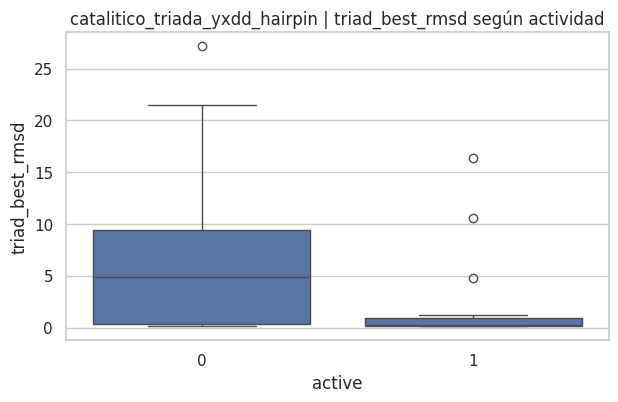

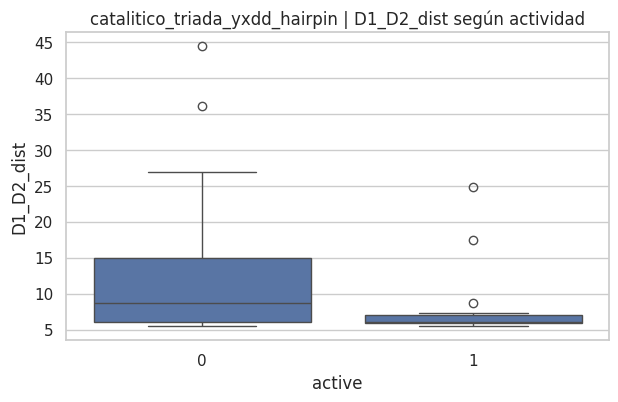

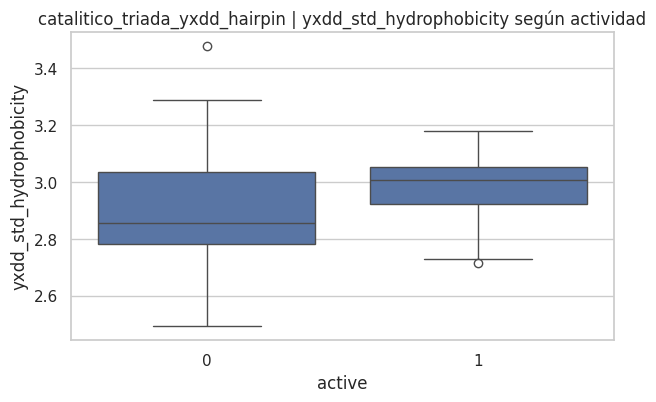

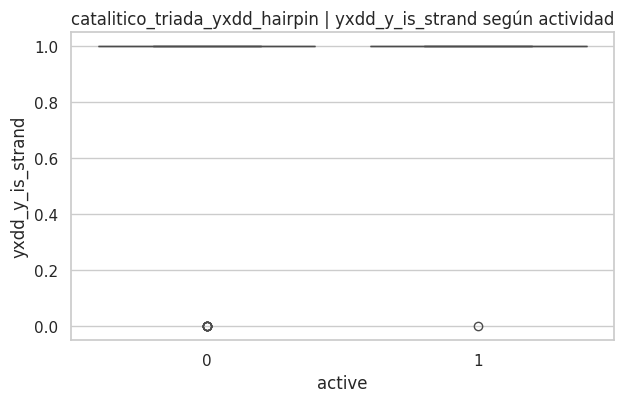

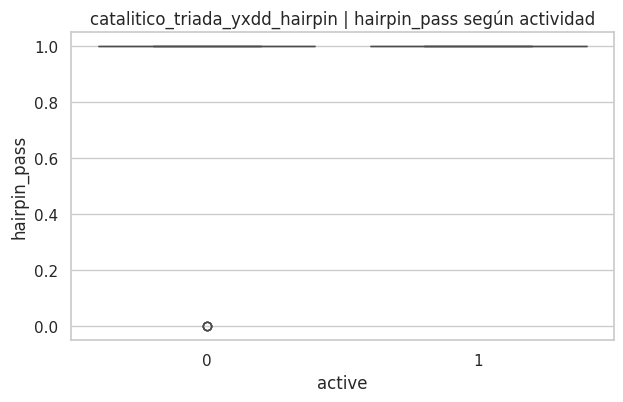

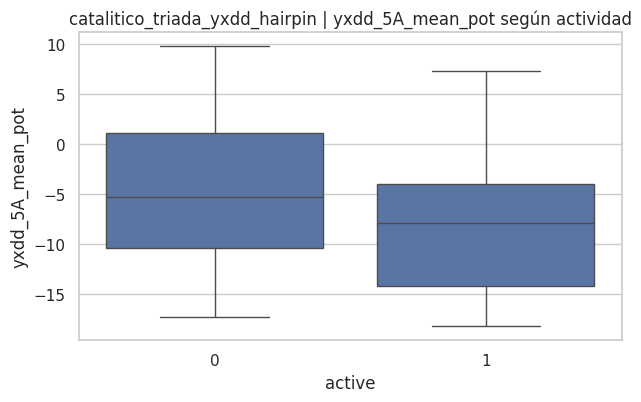

,feature,range_family_mean,std_family_mean
0,D1_D2_dist,20.854083,6.821117
4,triad_best_rmsd,17.882117,5.664723
6,yxdd_5A_mean_pot,15.187350,5.553849
3,hairpin_pass,1.000000,0.365366
10,yxdd_mean_hydrophobicity,0.937747,0.325699
5,triad_found_bin,0.400000,0.181060
13,yxdd_y_is_strand,0.400000,0.182248
12,yxdd_x_is_turn,0.400000,0.162691
8,yxdd_d2_is_strand,0.400000,0.162691
7,yxdd_d1_is_turn,0.400000,0.162691


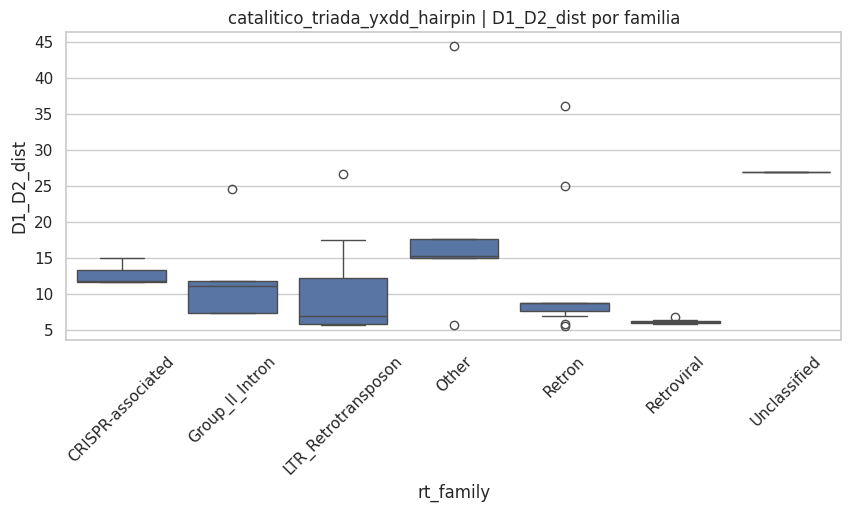

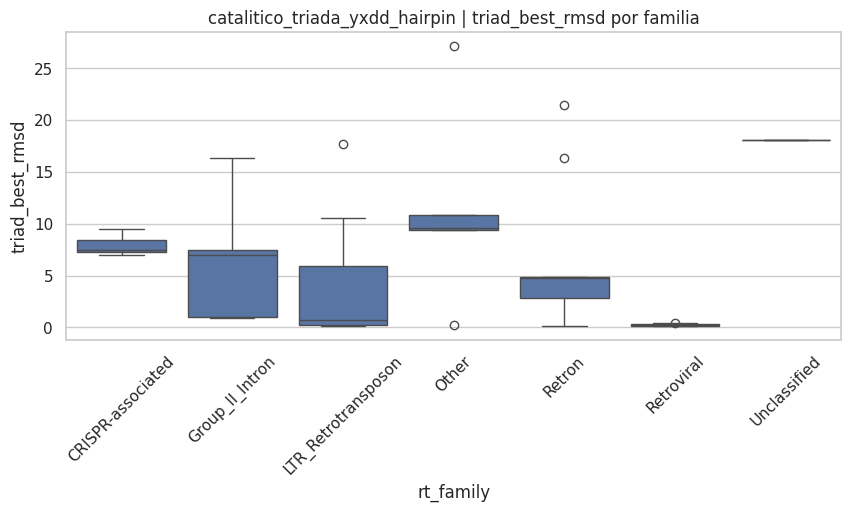

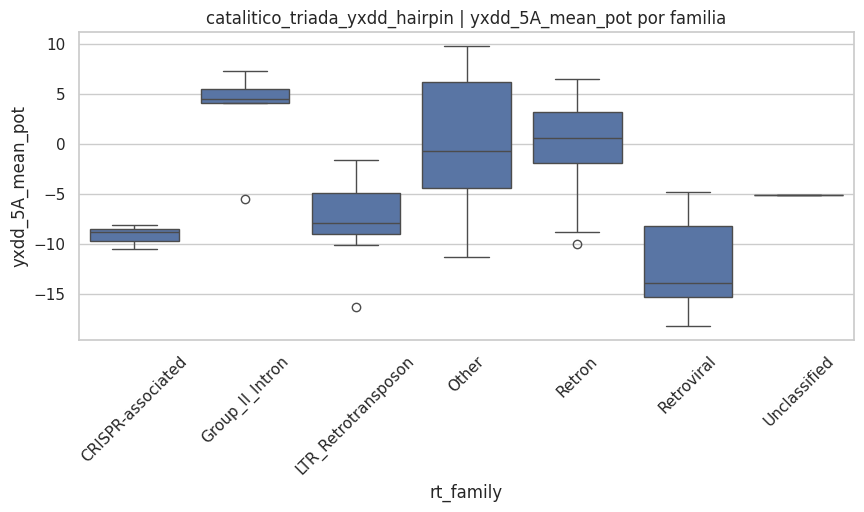

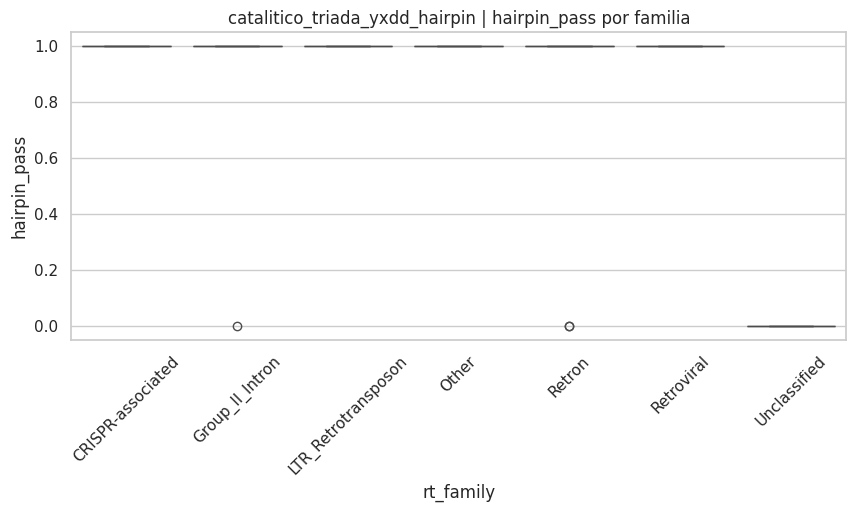

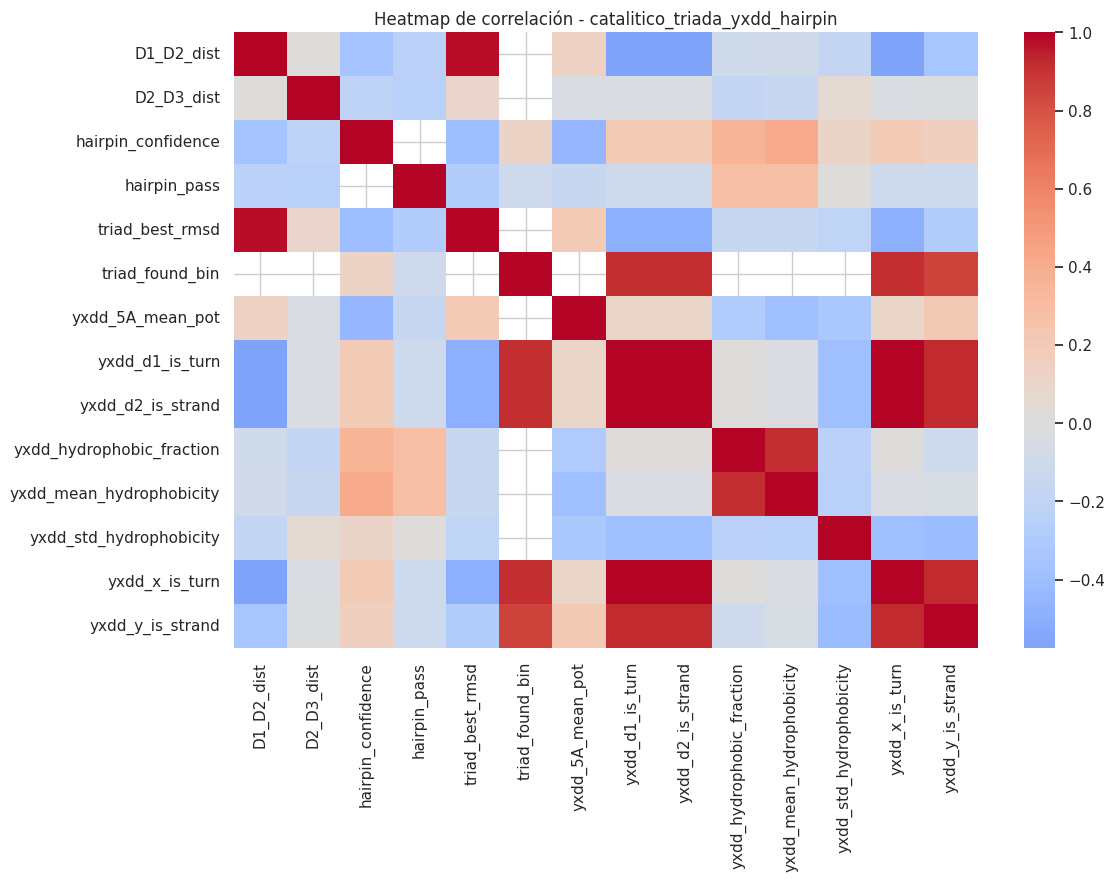


Missing por familia - bloque catalitico_triada_yxdd_hairpin


,feature,missing_pct
0,D1_D2_dist,12.280702
1,D2_D3_dist,12.280702
4,triad_best_rmsd,12.280702
11,yxdd_std_hydrophobicity,12.280702
9,yxdd_hydrophobic_fraction,12.280702
6,yxdd_5A_mean_pot,12.280702
10,yxdd_mean_hydrophobicity,12.280702
2,hairpin_confidence,7.017544
8,yxdd_d2_is_strand,1.754386
7,yxdd_d1_is_turn,1.754386


rt_family,CRISPR-associated,Group_II_Intron,LTR_Retrotransposon,Other,Retron,Retroviral,Unclassified
D1_D2_dist,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
D2_D3_dist,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
triad_best_rmsd,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
yxdd_std_hydrophobicity,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
yxdd_hydrophobic_fraction,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
yxdd_5A_mean_pot,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
yxdd_mean_hydrophobicity,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
hairpin_confidence,0.0,0.2,0.000000,0.0,0.166667,0.0,1.0


In [37]:
# ------------------------------------------------------------
# 5. BLOQUE CATALITICO: triad / YXDD / hairpin / distancias
# ------------------------------------------------------------
block_name = "catalitico_triada_yxdd_hairpin"
summary_df = block_summaries[block_name]

plot_top_boxplots_by_activity(train_df, summary_df, block_name, top_n=6)
plot_top_boxplots_by_family(train_df, summary_df, block_name, top_n=4)
plot_block_correlation_heatmap(train_df, block_dict[block_name], block_name, max_cols=20)
plot_missing_by_family_for_block(train_df, block_dict[block_name], block_name, top_n=8)

## 7) Visualizar bloque de hidrofobicidad y superficie

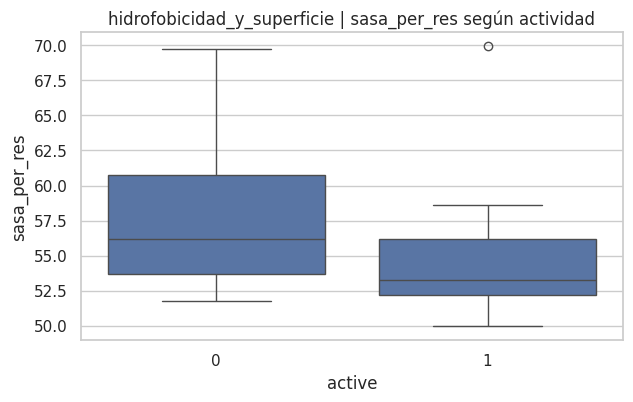

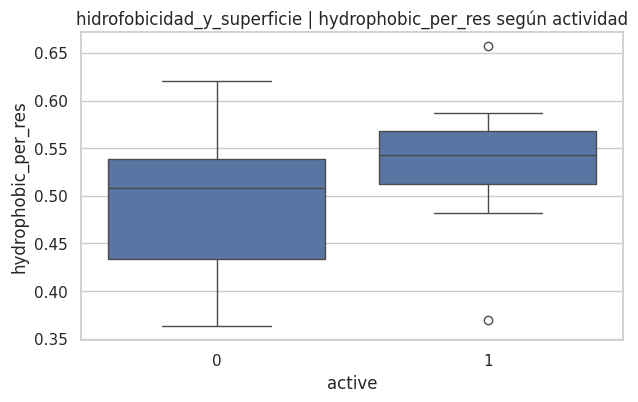

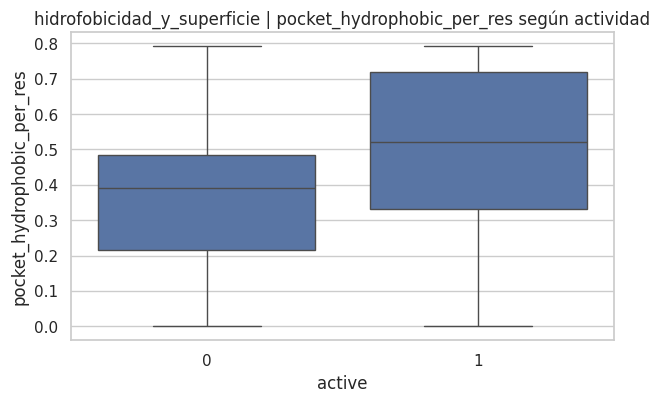

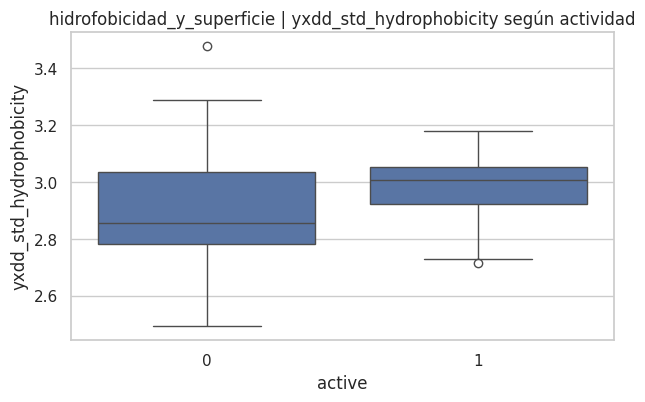

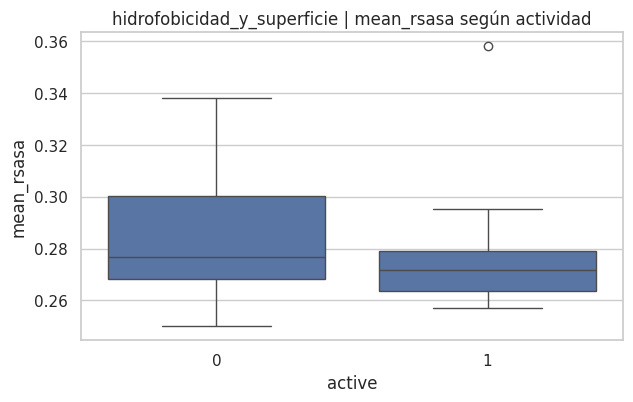

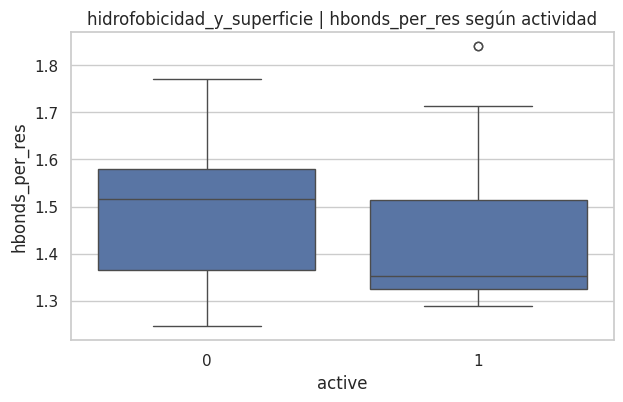

,feature,range_family_mean,std_family_mean
4,nterm_avg_sasa,18.935333,7.159782
8,sasa_per_res,15.400989,5.033500
12,yxdd_mean_hydrophobicity,0.937747,0.325699
6,pocket_hydrophobic_per_res,0.405417,0.150303
1,hbonds_per_res,0.353378,0.113688
5,pocket_hbonds_per_res,0.289818,0.102090
0,gravy,0.284498,0.095387
9,whole_mean_hydrophobicity,0.284483,0.095380
10,whole_std_hydrophobicity,0.214394,0.063307
11,yxdd_hydrophobic_fraction,0.198257,0.066975


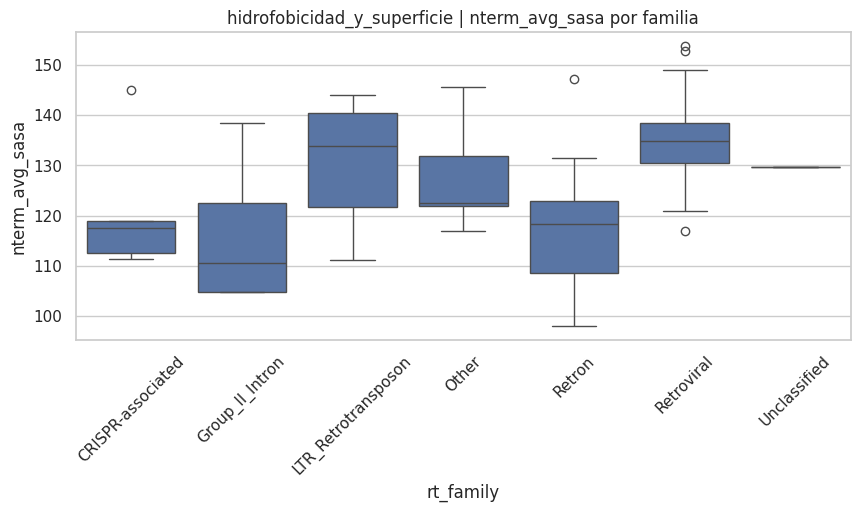

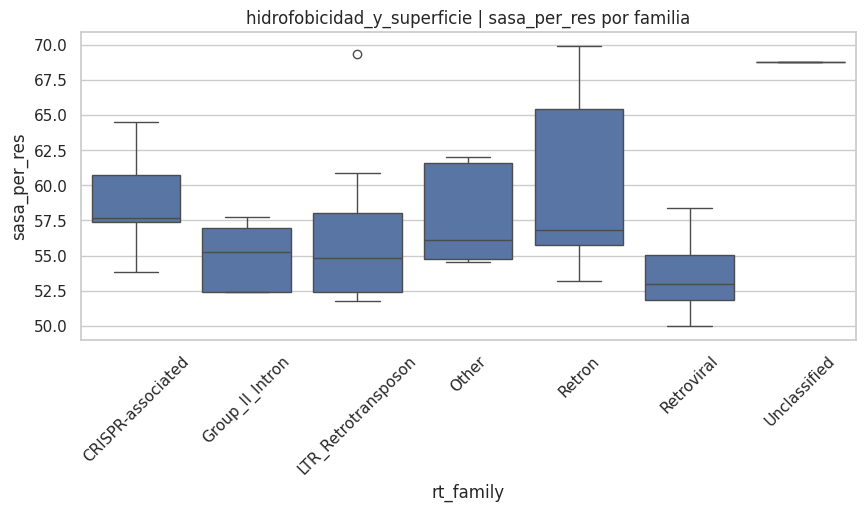

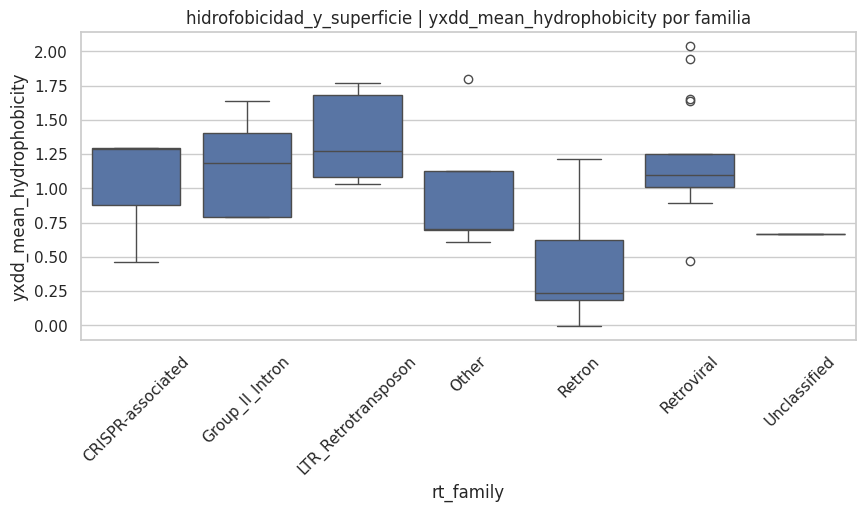

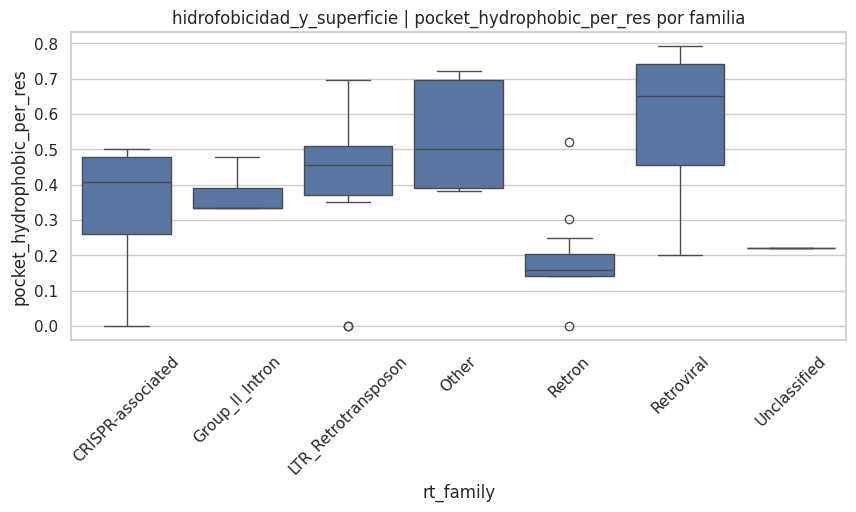

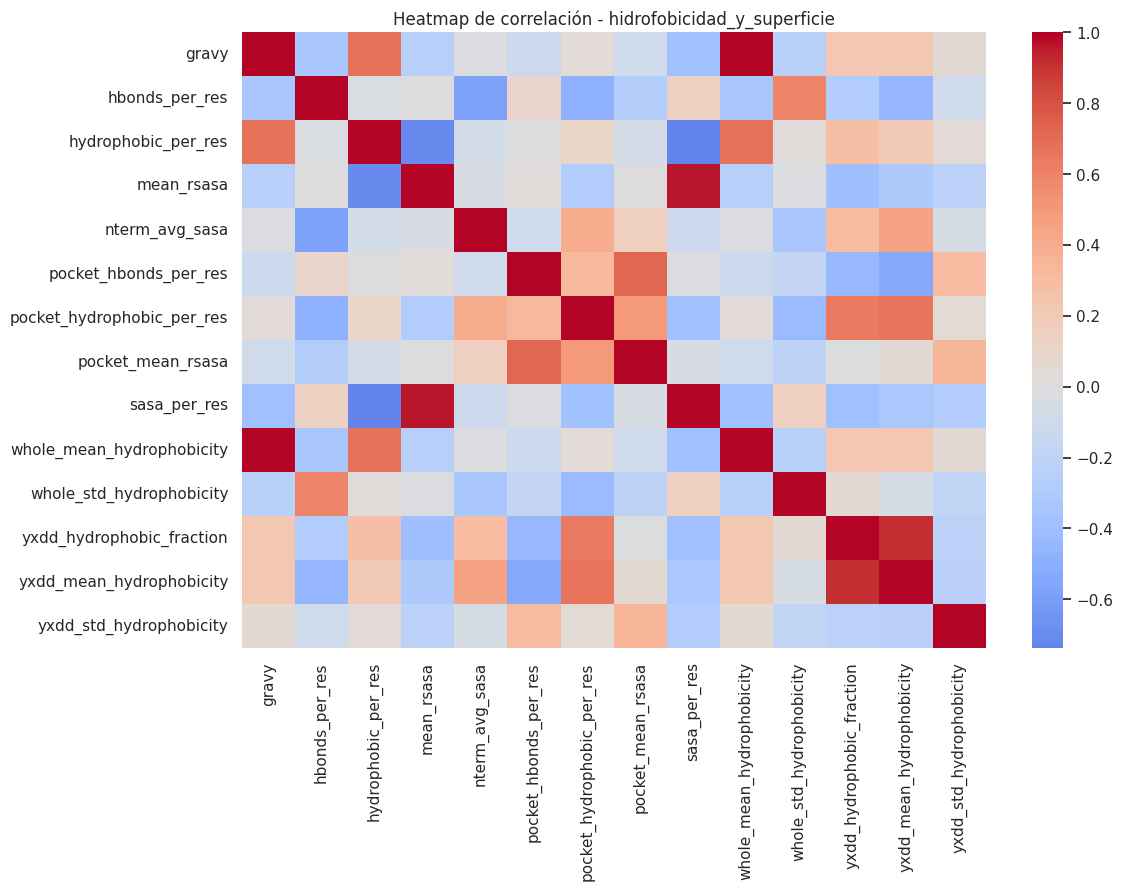


Missing por familia - bloque hidrofobicidad_y_superficie


,feature,missing_pct
13,yxdd_std_hydrophobicity,12.280702
12,yxdd_mean_hydrophobicity,12.280702
11,yxdd_hydrophobic_fraction,12.280702
2,hydrophobic_per_res,0.000000
0,gravy,0.000000
1,hbonds_per_res,0.000000
5,pocket_hbonds_per_res,0.000000
4,nterm_avg_sasa,0.000000
3,mean_rsasa,0.000000
6,pocket_hydrophobic_per_res,0.000000


rt_family,CRISPR-associated,Group_II_Intron,LTR_Retrotransposon,Other,Retron,Retroviral,Unclassified
yxdd_std_hydrophobicity,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
yxdd_mean_hydrophobicity,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
yxdd_hydrophobic_fraction,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0


In [38]:
# ------------------------------------------------------------
# 6. BLOQUE HIDROFOBICIDAD / SUPERFICIE / SASA / H-BONDS
# ------------------------------------------------------------
block_name = "hidrofobicidad_y_superficie"
summary_df = block_summaries[block_name]

plot_top_boxplots_by_activity(train_df, summary_df, block_name, top_n=6)
plot_top_boxplots_by_family(train_df, summary_df, block_name, top_n=4)
plot_block_correlation_heatmap(train_df, block_dict[block_name], block_name, max_cols=20)
plot_missing_by_family_for_block(train_df, block_dict[block_name], block_name, top_n=8)

## 8) Visualizar bloque electrostático

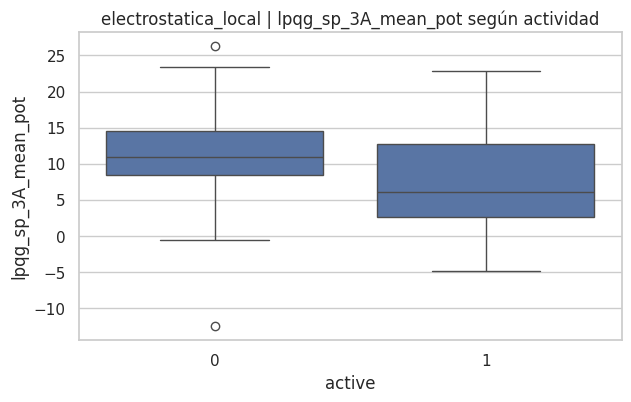

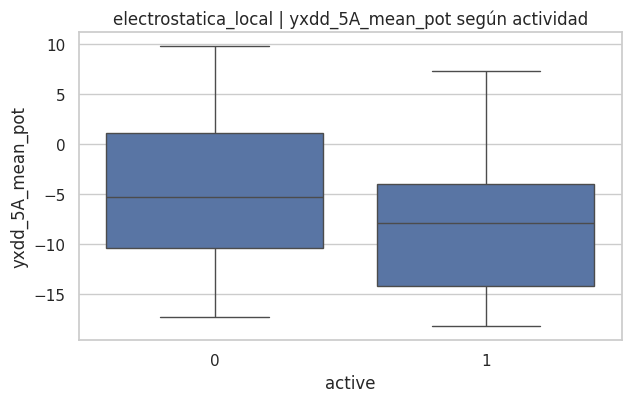

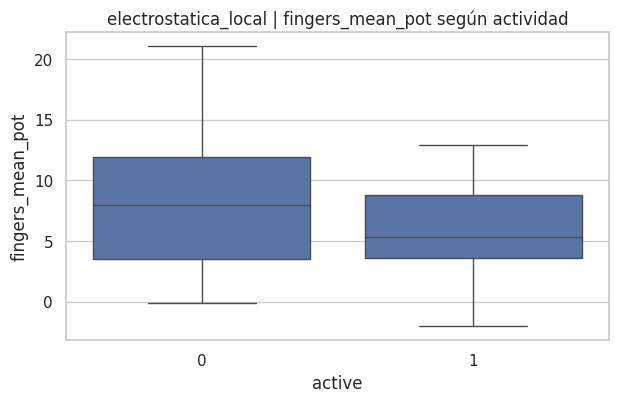

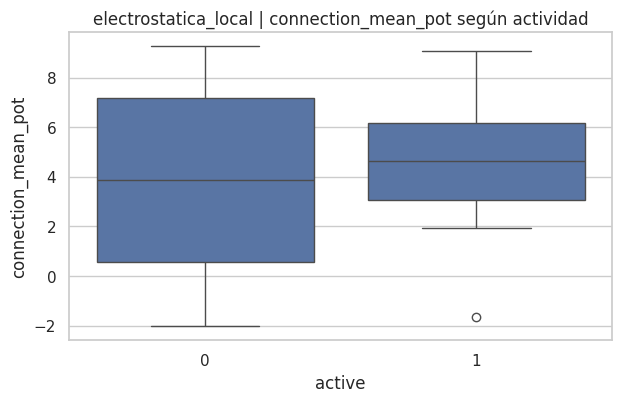

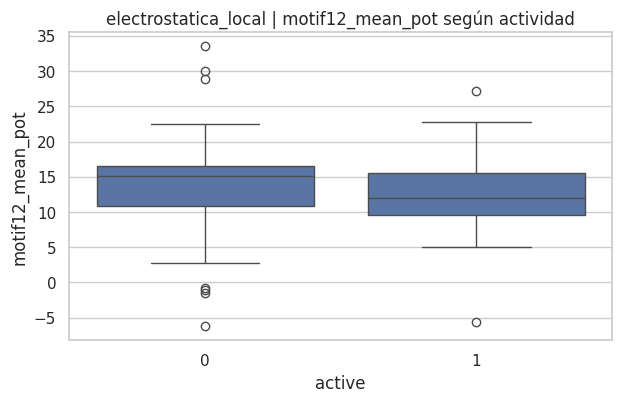

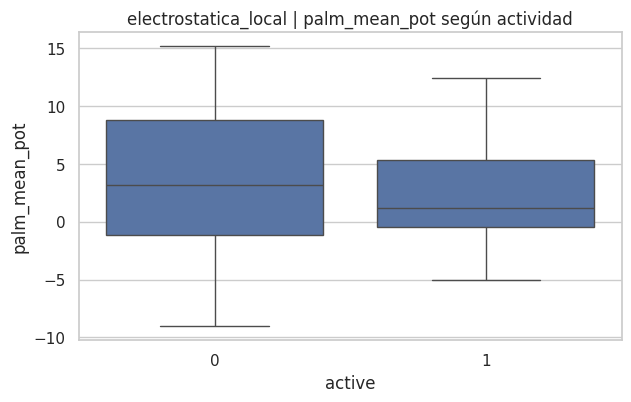

,feature,range_family_mean,std_family_mean
4,net_charge,32.600000,11.030041
7,thumb_mean_pot,15.811525,5.141942
8,yxdd_5A_mean_pot,15.187350,5.553849
6,palm_mean_pot,15.045873,5.098362
5,overall_mean_pot,14.040420,4.703056
2,lpqg_sp_3A_mean_pot,11.708230,4.295692
1,fingers_mean_pot,10.708820,3.831094
3,motif12_mean_pot,10.194492,3.659608
0,connection_mean_pot,3.362680,1.765913


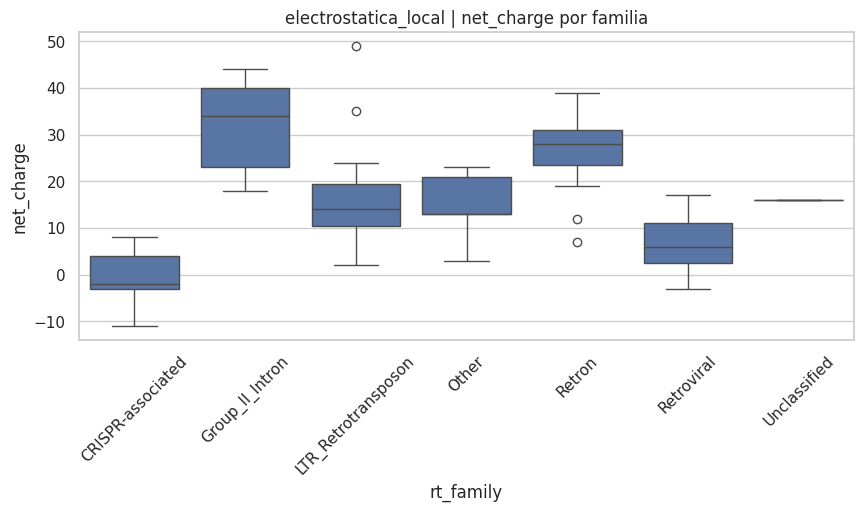

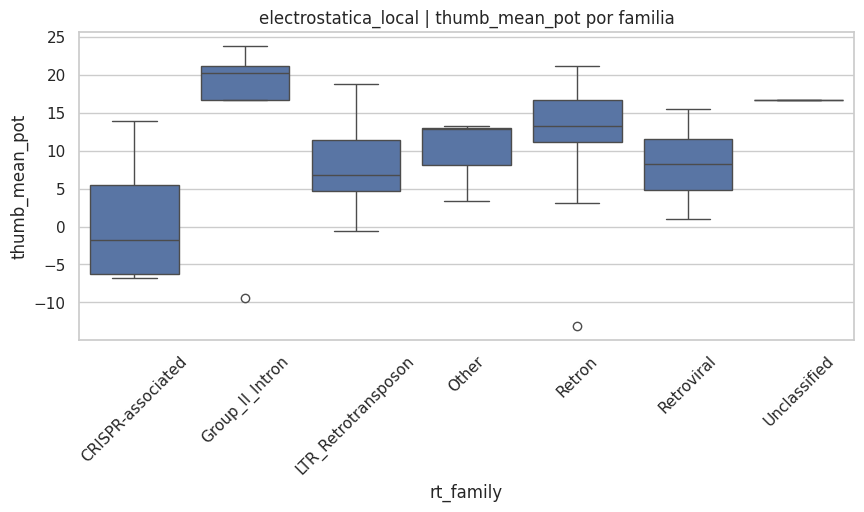

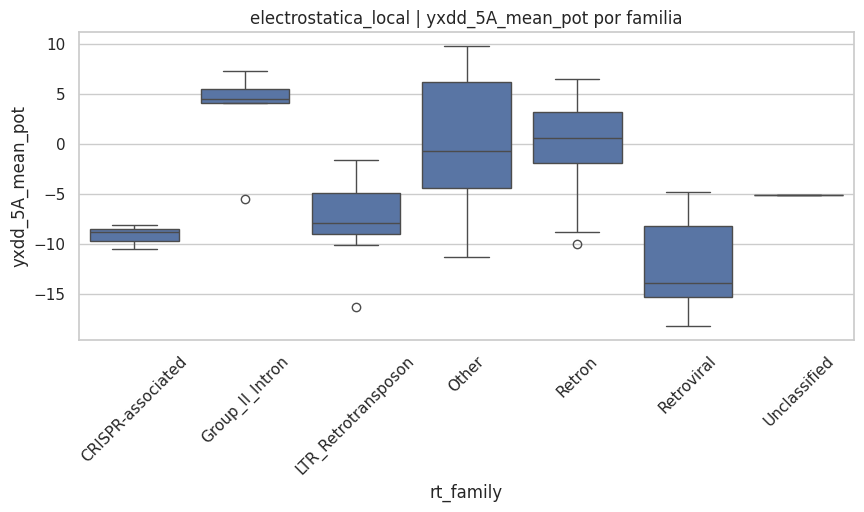

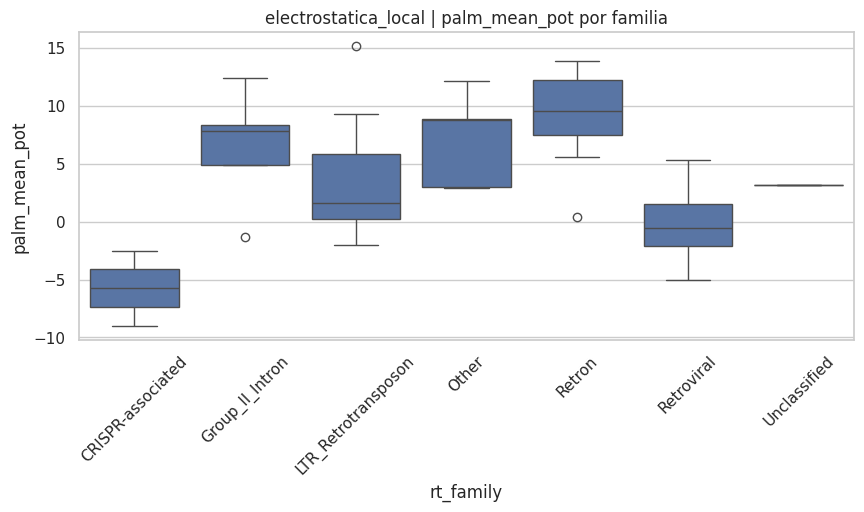

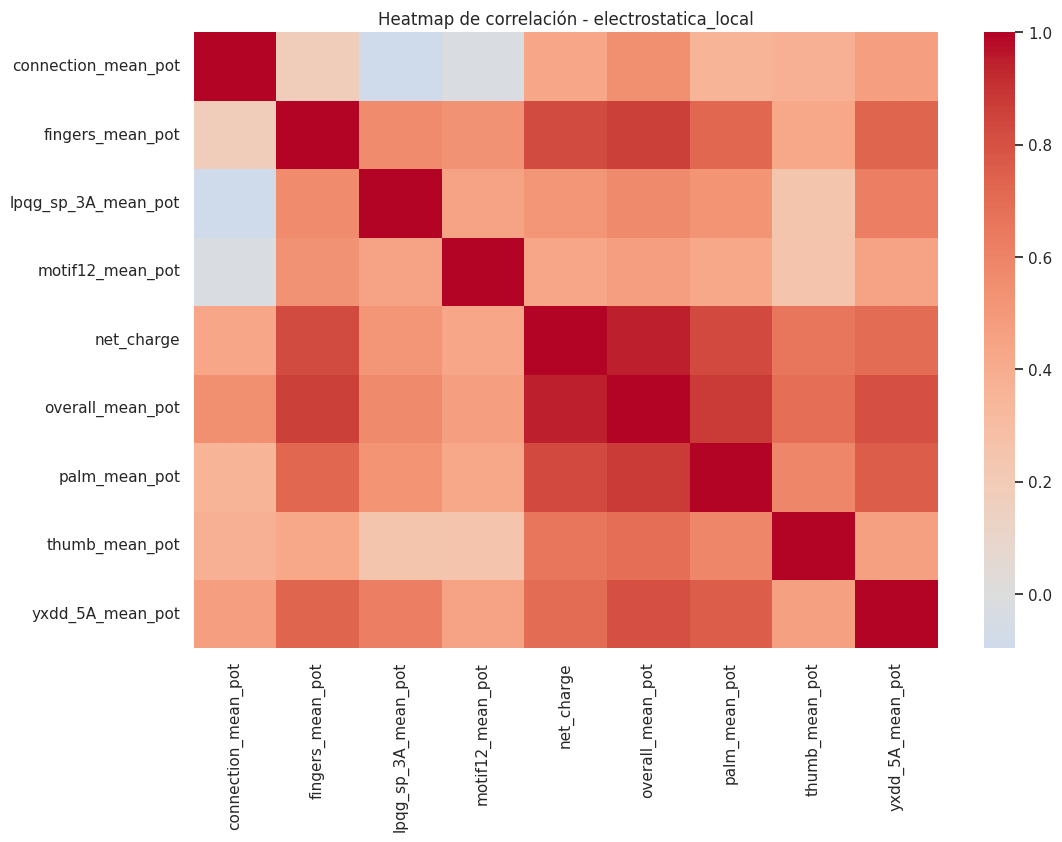


Missing por familia - bloque electrostatica_local


,feature,missing_pct
0,connection_mean_pot,57.894737
8,yxdd_5A_mean_pot,12.280702
7,thumb_mean_pot,1.754386
1,fingers_mean_pot,0.000000
2,lpqg_sp_3A_mean_pot,0.000000
4,net_charge,0.000000
3,motif12_mean_pot,0.000000
6,palm_mean_pot,0.000000
5,overall_mean_pot,0.000000


rt_family,CRISPR-associated,Group_II_Intron,LTR_Retrotransposon,Other,Retron,Retroviral,Unclassified
connection_mean_pot,1.0,1.0,0.545455,0.8,1.000000,0.0,1.0
yxdd_5A_mean_pot,0.4,0.0,0.363636,0.0,0.083333,0.0,0.0
thumb_mean_pot,0.2,0.0,0.000000,0.0,0.000000,0.0,0.0


In [39]:
# ------------------------------------------------------------
# 7. BLOQUE ELECTROSTATICA LOCAL
# ------------------------------------------------------------
block_name = "electrostatica_local"
summary_df = block_summaries[block_name]

plot_top_boxplots_by_activity(train_df, summary_df, block_name, top_n=6)
plot_top_boxplots_by_family(train_df, summary_df, block_name, top_n=4)
plot_block_correlation_heatmap(train_df, block_dict[block_name], block_name, max_cols=20)
plot_missing_by_family_for_block(train_df, block_dict[block_name], block_name, top_n=8)

## 9) Visualizar bloque de estabilidad / termoestabilidad


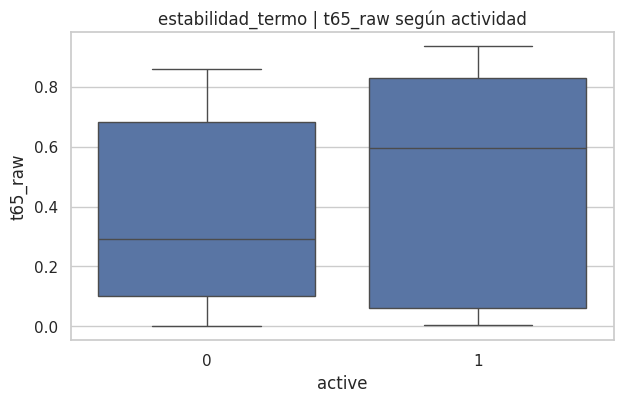

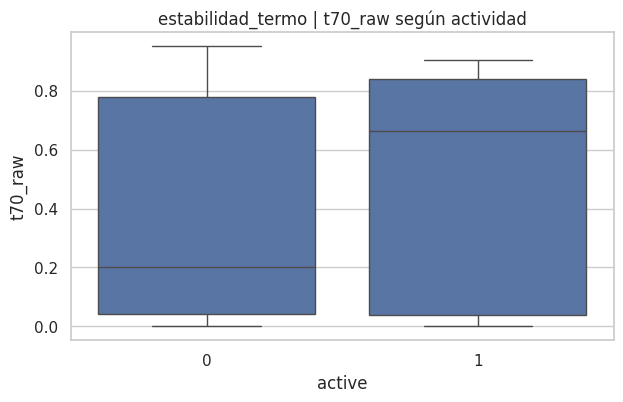

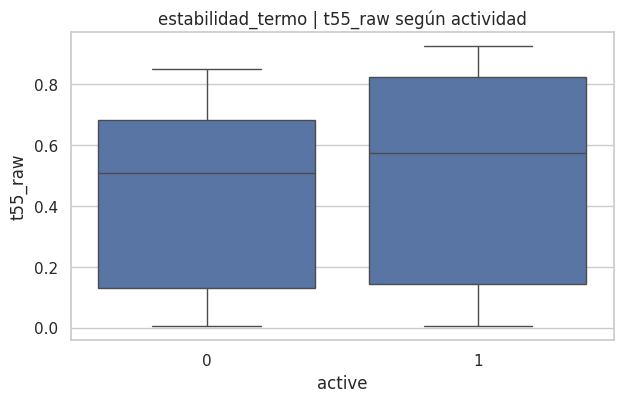

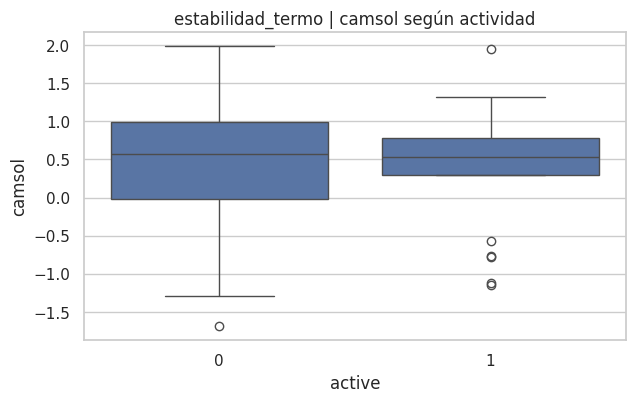

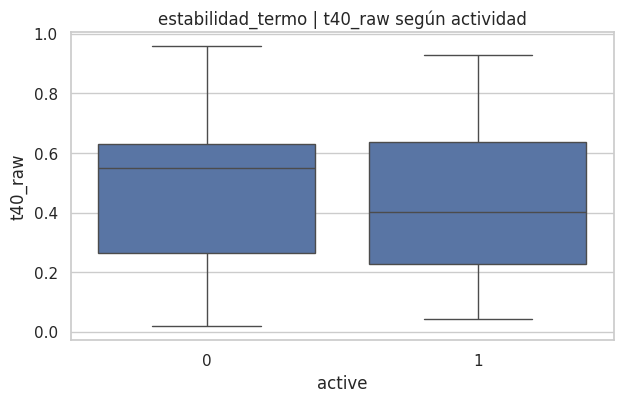

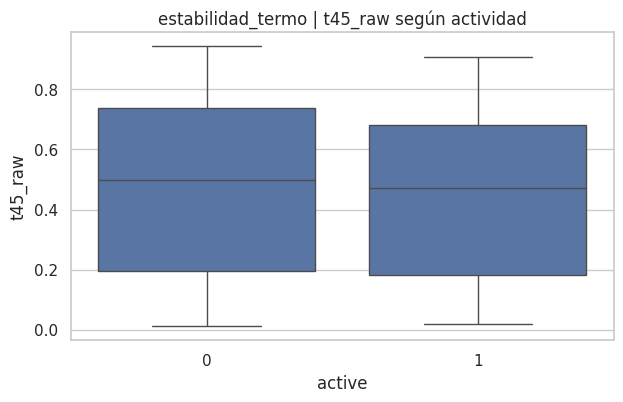

,feature,range_family_mean,std_family_mean
1,instability_index,5.956863,2.285571
11,thermophilicity_num,1.833333,0.694613
0,camsol,1.293979,0.531356
8,t70_raw,0.752652,0.310956
7,t65_raw,0.659896,0.254095
9,t75_raw,0.624792,0.247629
10,t80_raw,0.513683,0.196825
5,t55_raw,0.498788,0.185489
3,t45_raw,0.393844,0.160798
2,t40_raw,0.383568,0.143509


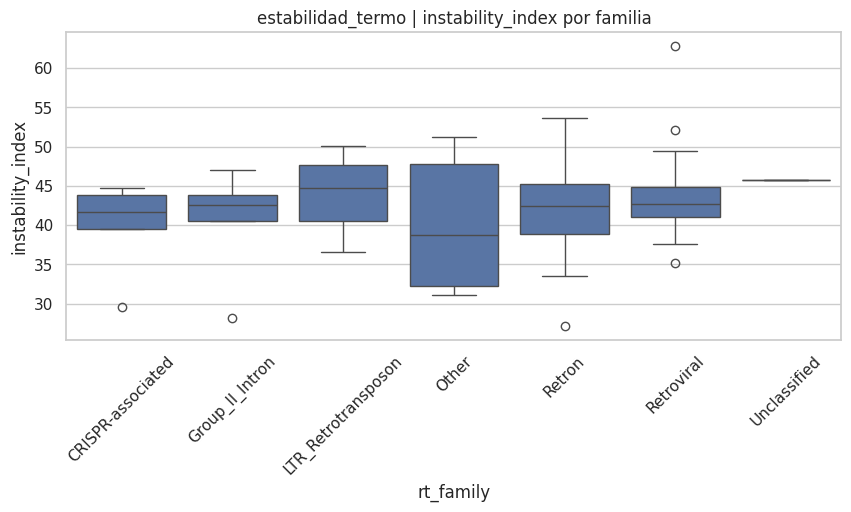

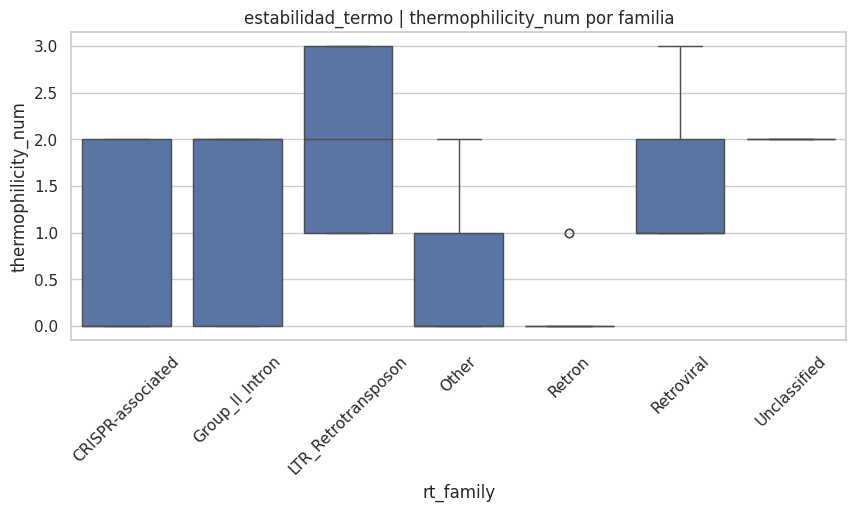

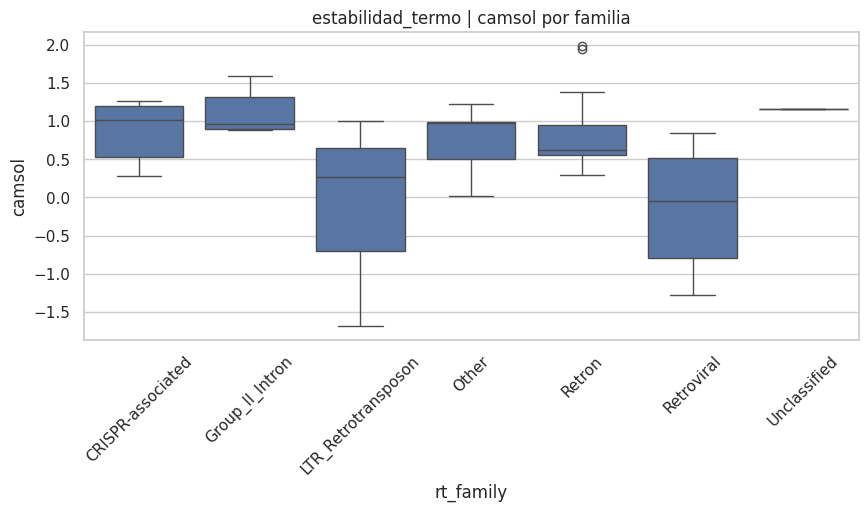

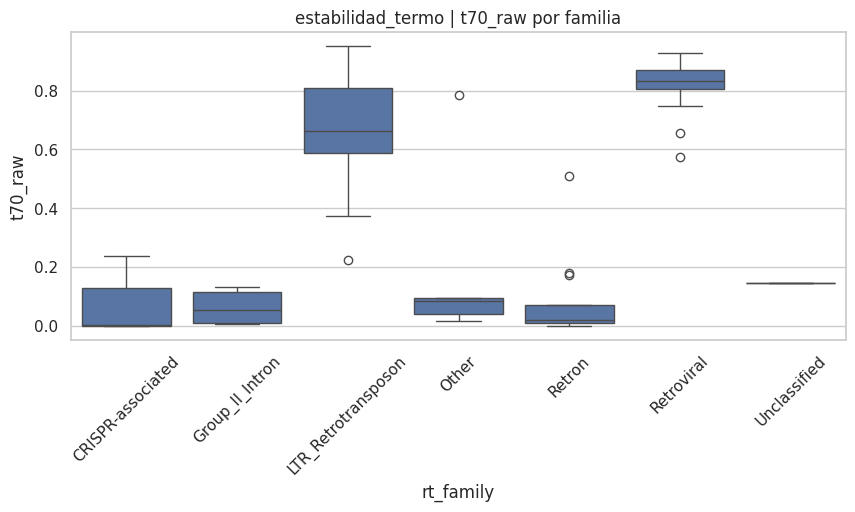

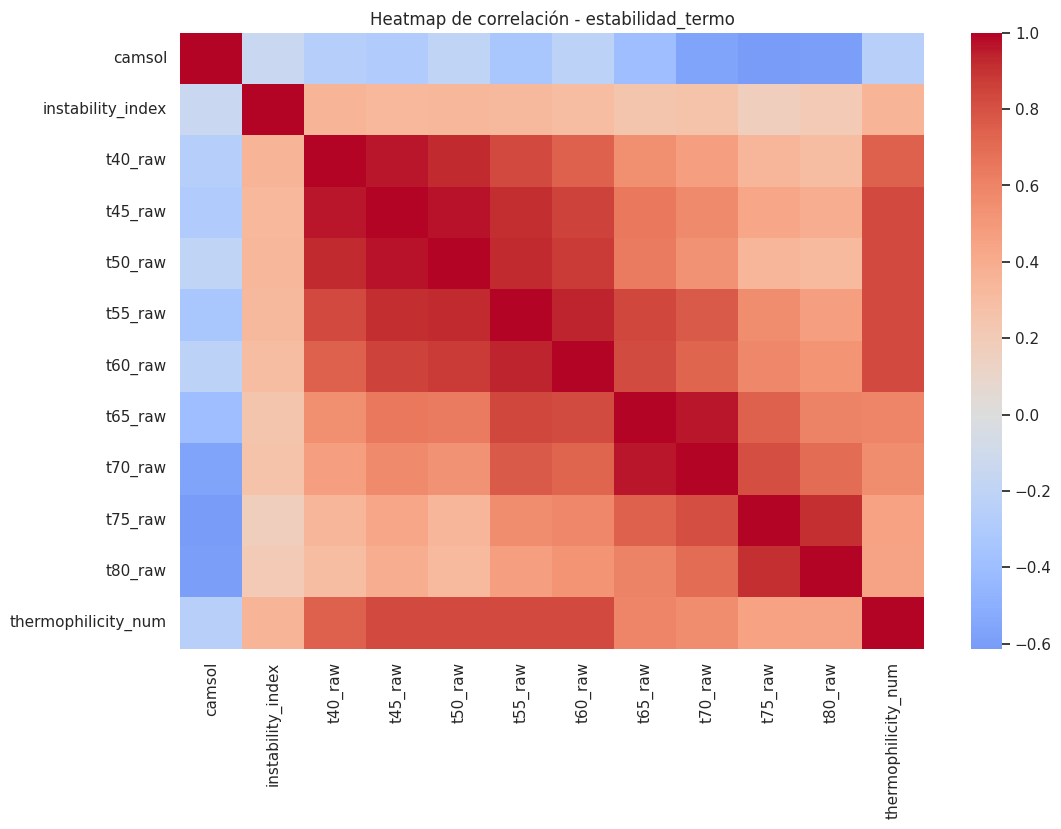

No hay missing values relevantes en el bloque estabilidad_termo.


In [40]:
# ------------------------------------------------------------
# 8. BLOQUE ESTABILIDAD / TERMOESTABILIDAD
# ------------------------------------------------------------
block_name = "estabilidad_termo"
summary_df = block_summaries[block_name]

plot_top_boxplots_by_activity(train_df, summary_df, block_name, top_n=6)
plot_top_boxplots_by_family(train_df, summary_df, block_name, top_n=4)
plot_block_correlation_heatmap(train_df, block_dict[block_name], block_name, max_cols=20)
plot_missing_by_family_for_block(train_df, block_dict[block_name], block_name, top_n=8)

## 10) Visualizar bloque FoldSeek

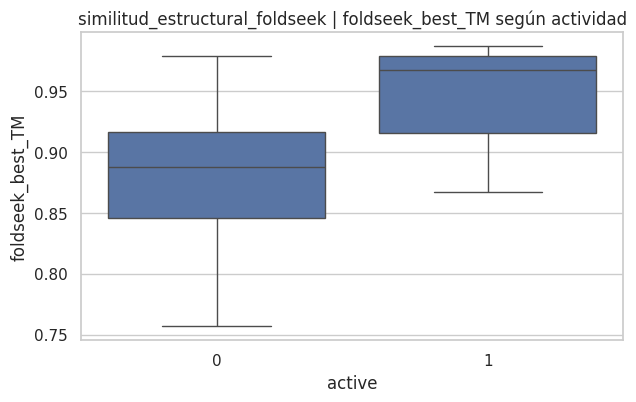

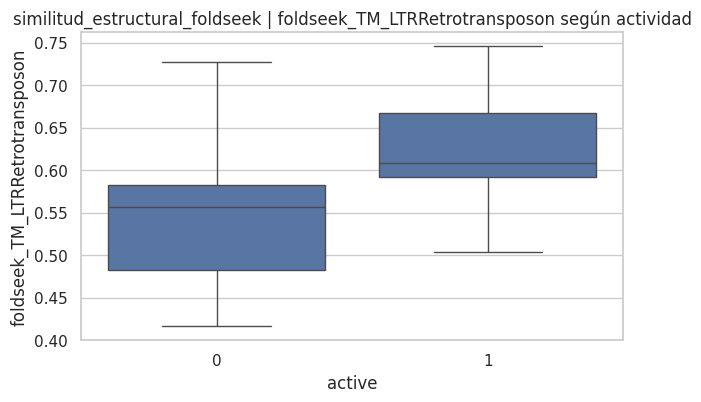

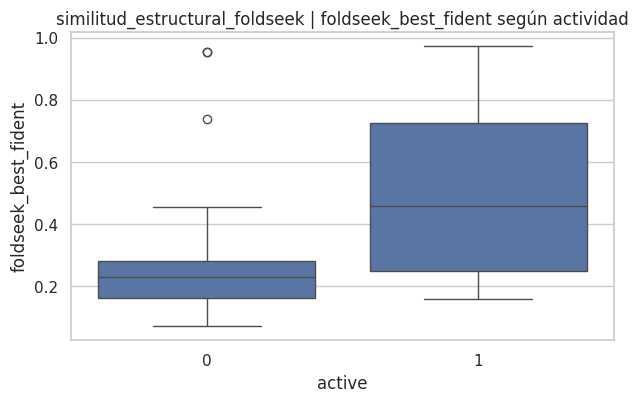

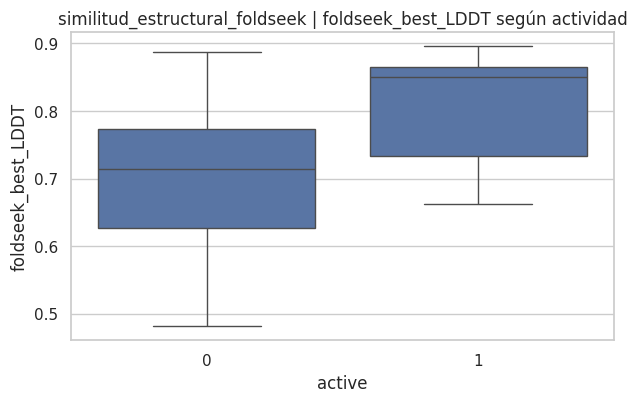

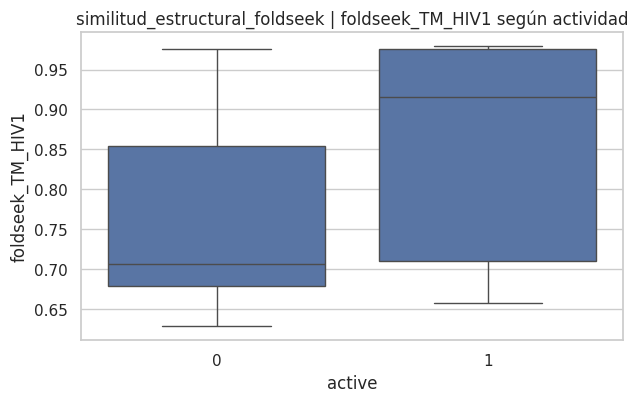

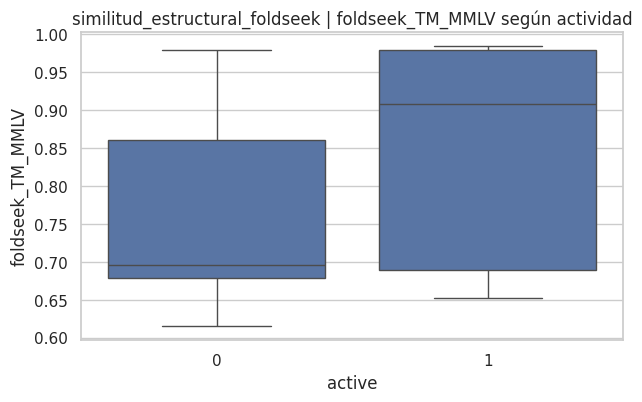

,feature,range_family_mean,std_family_mean
4,foldseek_TM_MMLVPE,0.363246,0.111709
9,foldseek_best_fident,0.357764,0.161163
0,foldseek_TM_Group2Intron,0.283278,0.109914
1,foldseek_TM_HIV1,0.260640,0.094427
3,foldseek_TM_MMLV,0.260342,0.095152
6,foldseek_TM_Telomerase,0.199268,0.082299
5,foldseek_TM_Retron,0.190999,0.071818
7,foldseek_best_LDDT,0.183297,0.074141
8,foldseek_best_TM,0.156456,0.054518
2,foldseek_TM_LTRRetrotransposon,0.150998,0.047181


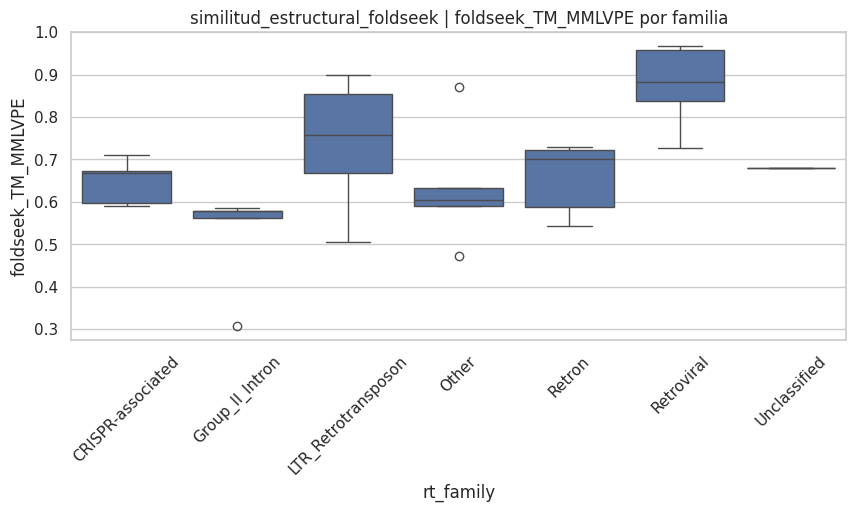

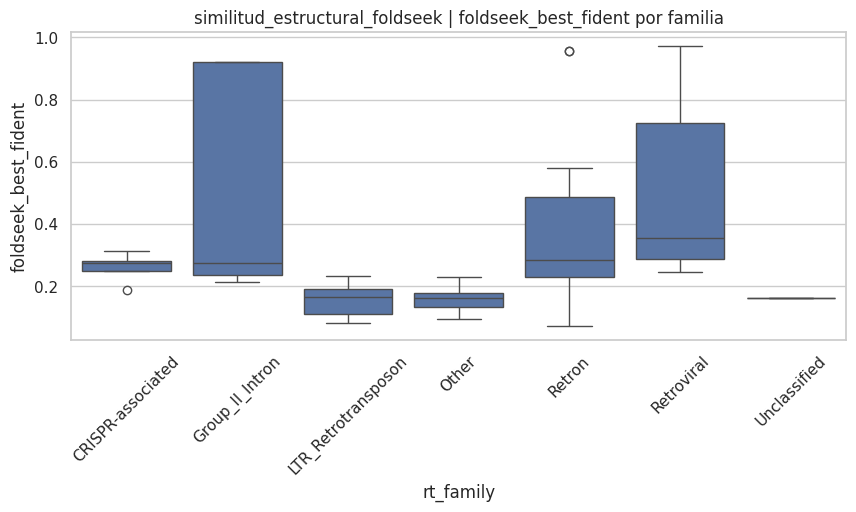

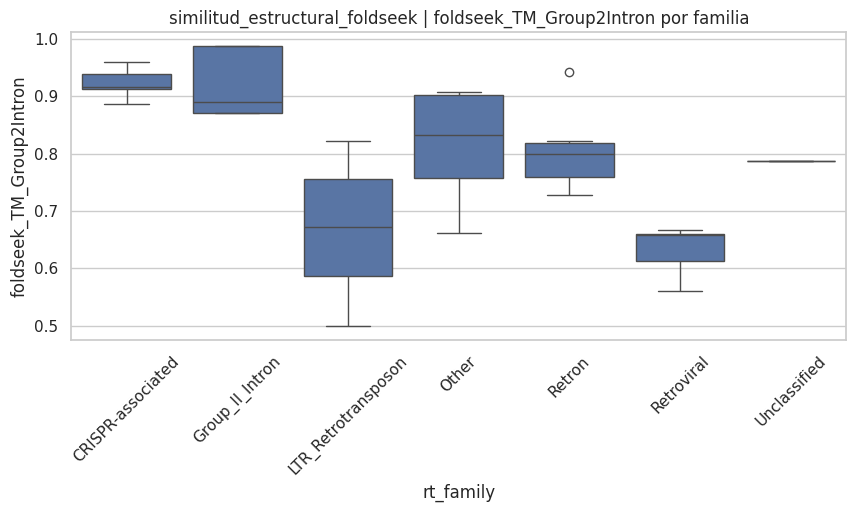

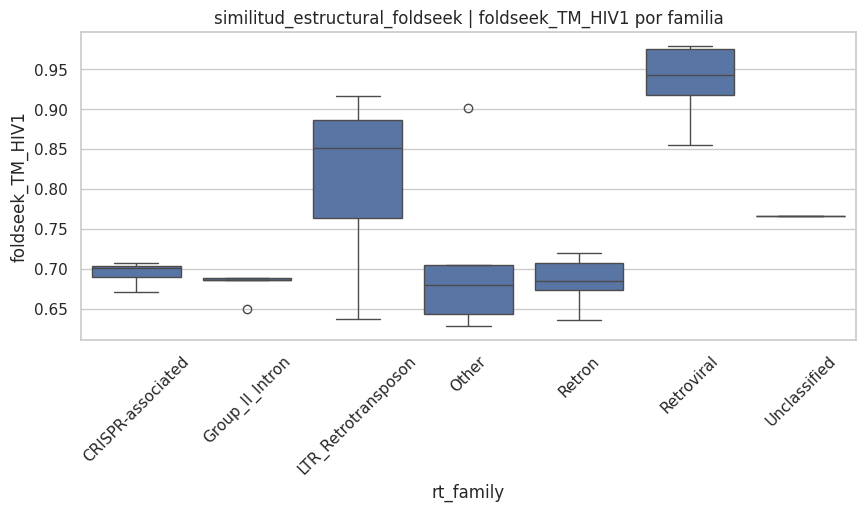

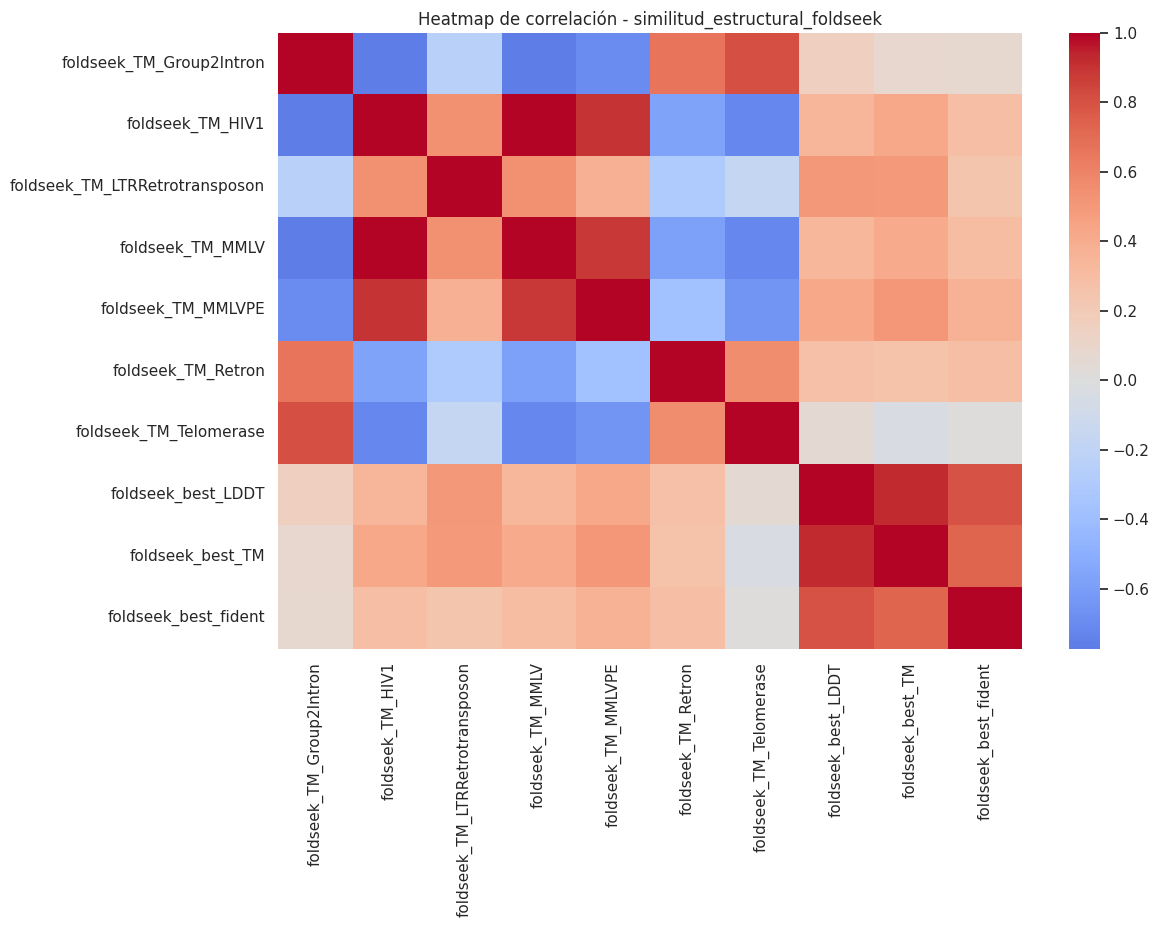

No hay missing values relevantes en el bloque similitud_estructural_foldseek.


In [41]:
# ------------------------------------------------------------
# 9. BLOQUE SIMILITUD ESTRUCTURAL - FOLDSEEK
# ------------------------------------------------------------
block_name = "similitud_estructural_foldseek"
summary_df = block_summaries[block_name]

plot_top_boxplots_by_activity(train_df, summary_df, block_name, top_n=6)
plot_top_boxplots_by_family(train_df, summary_df, block_name, top_n=4)
plot_block_correlation_heatmap(train_df, block_dict[block_name], block_name, max_cols=20)
plot_missing_by_family_for_block(train_df, block_dict[block_name], block_name, top_n=8)

## 11) Visualizar bloque de metadata global

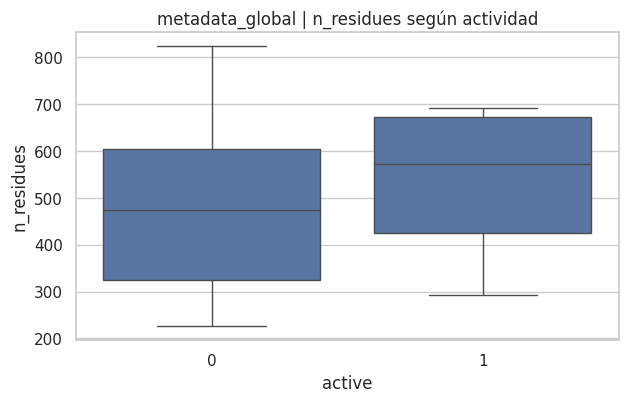

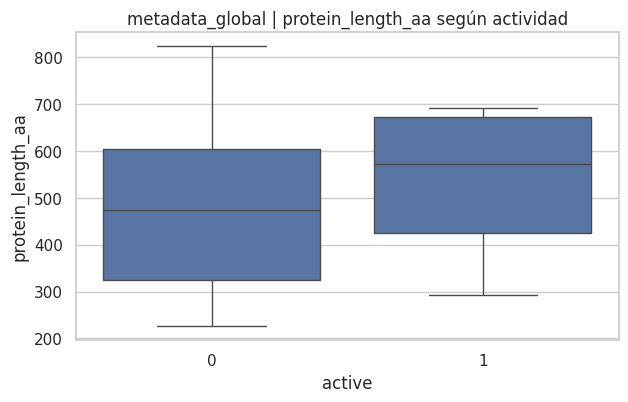

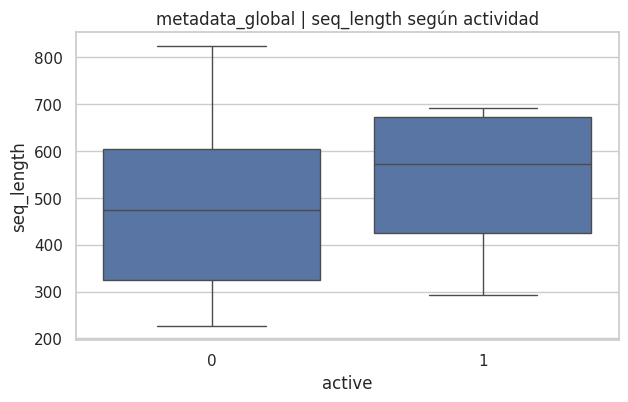

,feature,range_family_mean,std_family_mean
0,n_residues,415.222222,136.269390
1,protein_length_aa,415.222222,136.221787
2,seq_length,415.222222,136.221787


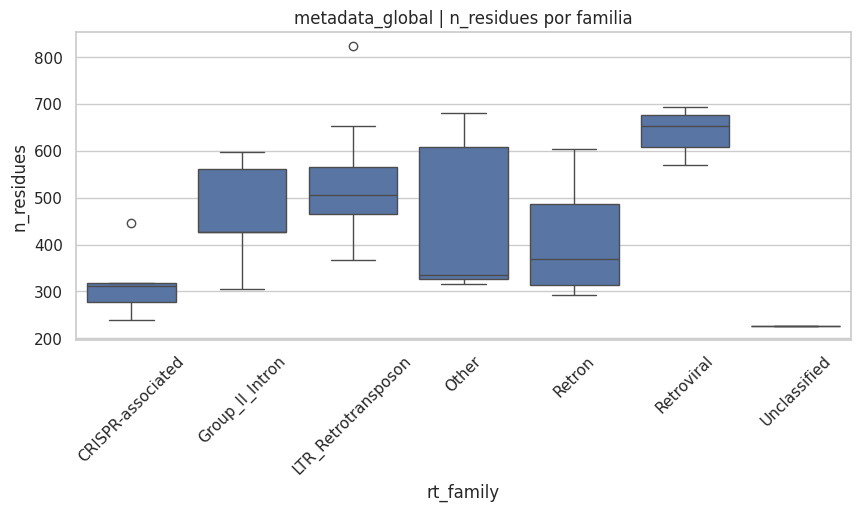

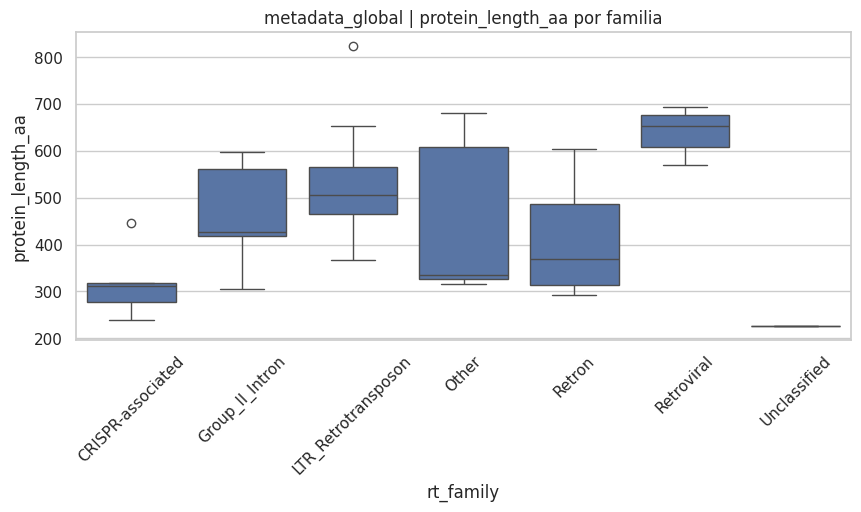

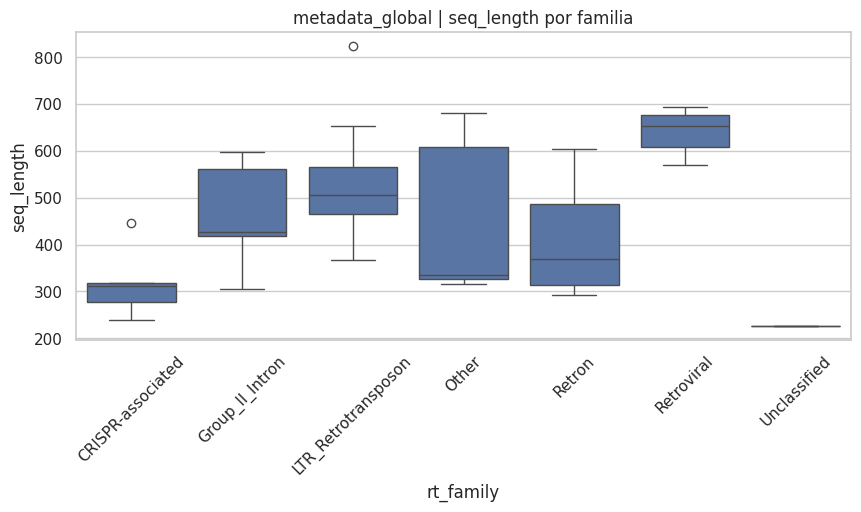

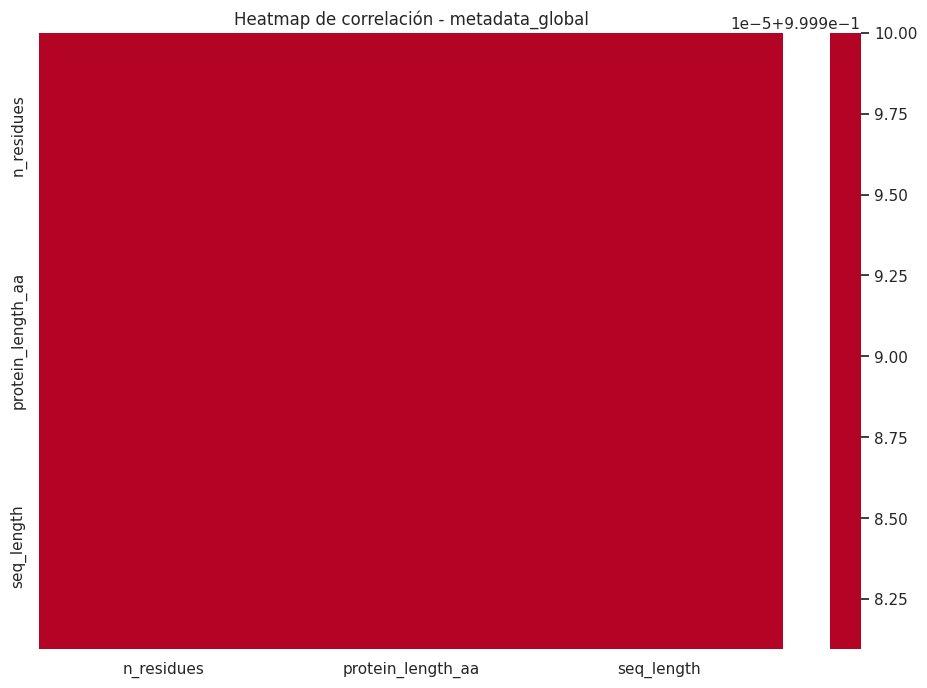

No hay missing values relevantes en el bloque metadata_global.


In [42]:
# ------------------------------------------------------------
# 10. BLOQUE METADATA GLOBAL
# ------------------------------------------------------------
block_name = "metadata_global"
summary_df = block_summaries[block_name]

plot_top_boxplots_by_activity(train_df, summary_df, block_name, top_n=6)
plot_top_boxplots_by_family(train_df, summary_df, block_name, top_n=4)
plot_block_correlation_heatmap(train_df, block_dict[block_name], block_name, max_cols=20)
plot_missing_by_family_for_block(train_df, block_dict[block_name], block_name, top_n=8)

## 12) Visualizar bloque de modelo de secuencia global

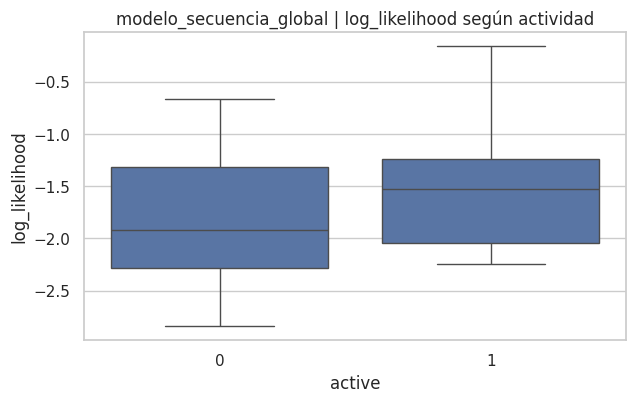

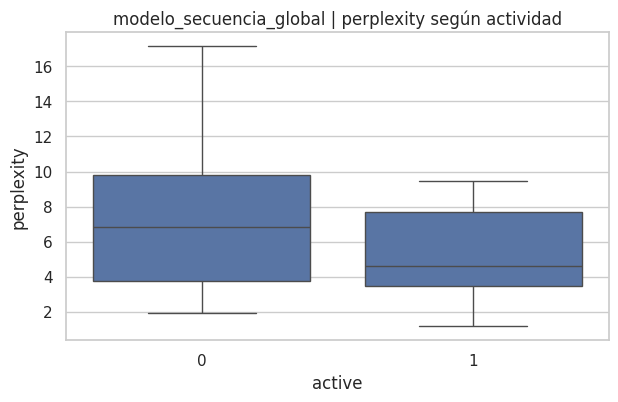

,feature,range_family_mean,std_family_mean
1,perplexity,6.340337,2.135699
0,log_likelihood,1.155128,0.388907


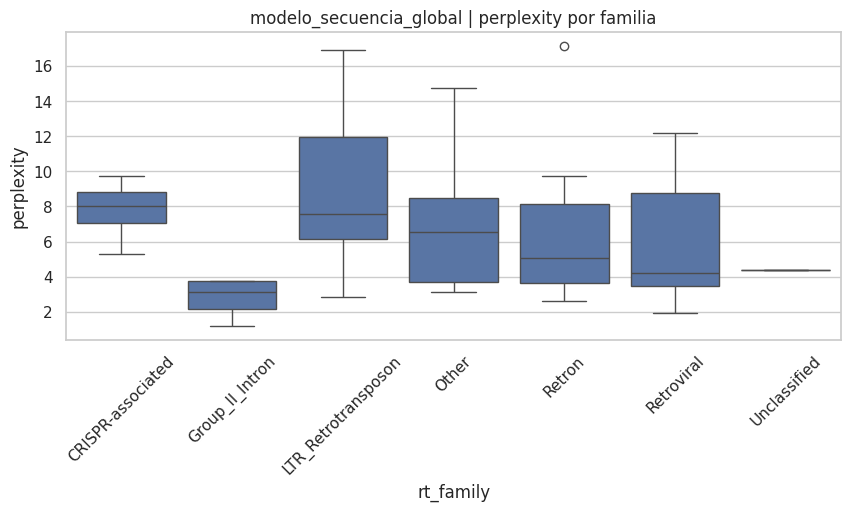

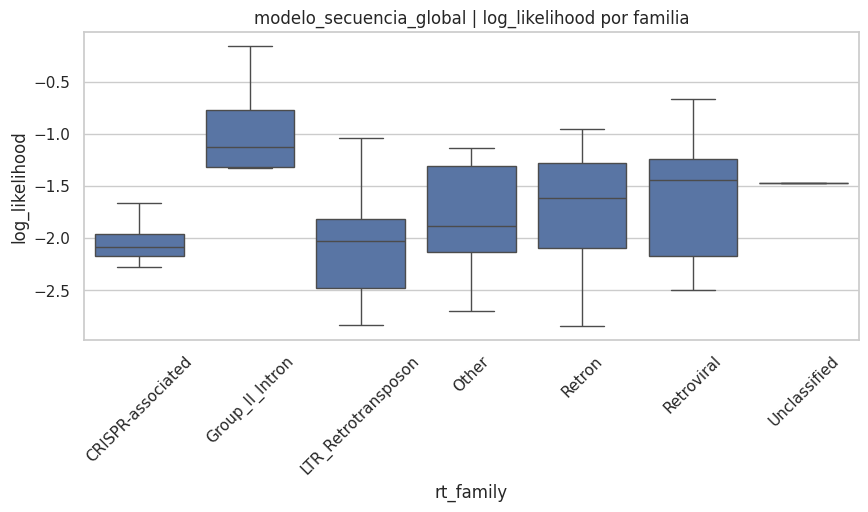

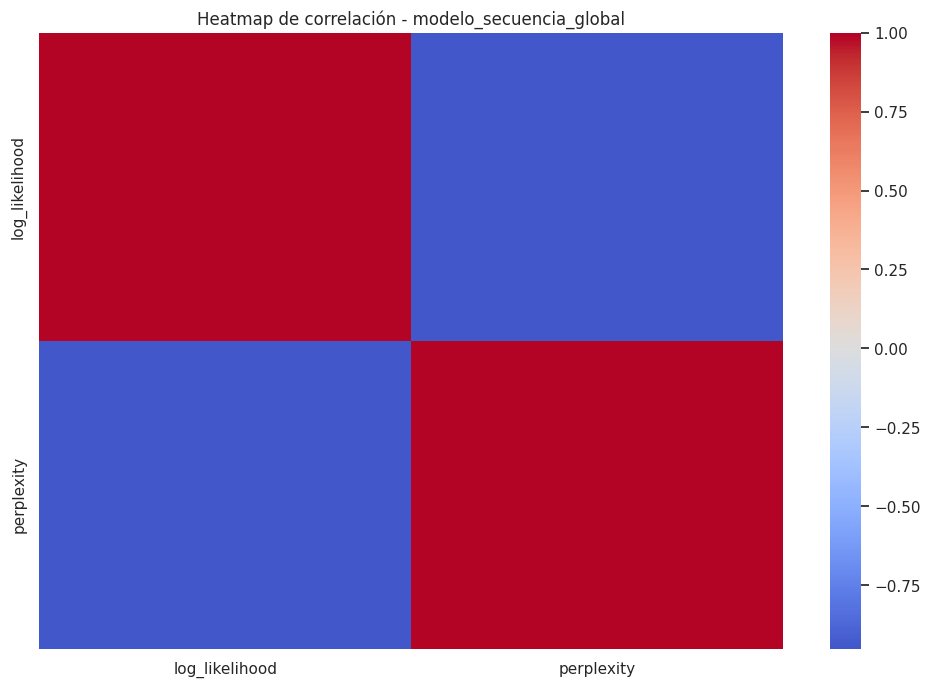

No hay missing values relevantes en el bloque modelo_secuencia_global.


In [43]:
# ------------------------------------------------------------
# 11. BLOQUE MODELO DE SECUENCIA GLOBAL
# ------------------------------------------------------------
block_name = "modelo_secuencia_global"
summary_df = block_summaries[block_name]

plot_top_boxplots_by_activity(train_df, summary_df, block_name, top_n=6)
plot_top_boxplots_by_family(train_df, summary_df, block_name, top_n=4)
plot_block_correlation_heatmap(train_df, block_dict[block_name], block_name, max_cols=20)
plot_missing_by_family_for_block(train_df, block_dict[block_name], block_name, top_n=8)

## 13) Tabla resumen por bloque

In [44]:
# ------------------------------------------------------------
# 12. Tabla resumen comparativa por bloque
# ------------------------------------------------------------
block_level_rows = []

for block_name, summary_df in block_summaries.items():
    if summary_df is None or len(summary_df) == 0:
        continue
    
    block_level_rows.append({
        "block": block_name,
        "n_features": len(summary_df),
        "mean_missing_pct": summary_df["missing_pct"].mean(),
        "max_abs_corr_active": summary_df["abs_act"].max(),
        "mean_abs_corr_active": summary_df["abs_act"].mean(),
        "max_abs_corr_efficiency": summary_df["abs_eff"].max(),
        "mean_abs_corr_efficiency": summary_df["abs_eff"].mean(),
    })

block_level_df = pd.DataFrame(block_level_rows).sort_values(
    "max_abs_corr_efficiency", ascending=False
)

display(block_level_df)

,block,n_features,mean_missing_pct,max_abs_corr_active,mean_abs_corr_active,max_abs_corr_efficiency,mean_abs_corr_efficiency
5,similitud_estructural_foldseek,10,0.000000,0.550472,0.355714,0.565791,0.407295
1,catalitico_triada_yxdd_hairpin,14,7.142857,0.347966,0.199342,0.402538,0.222302
3,electrostatica_local,9,7.992203,0.291807,0.127038,0.375233,0.176528
2,hidrofobicidad_y_superficie,14,2.631579,0.322761,0.174718,0.369744,0.209519
0,metadata_global,3,0.000000,0.221098,0.220354,0.299960,0.299738
4,estabilidad_termo,12,0.000000,0.185695,0.071748,0.288001,0.117602
6,modelo_secuencia_global,2,0.000000,0.249804,0.249804,0.274549,0.274549


## 14) Score simple de “sesgo de familia” por feature

In [45]:
# ------------------------------------------------------------
# 13. Medir cuánto varía cada feature entre familias
# ------------------------------------------------------------
family_bias_rows = []

for block_name, cols in block_dict.items():
    num_cols = get_numeric_block_cols(train_df, cols)
    
    for col in num_cols:
        means = train_df.groupby("rt_family")[col].mean()
        
        family_bias_rows.append({
            "block": block_name,
            "feature": col,
            "range_family_mean": means.max() - means.min(),
            "std_family_mean": means.std(),
            "spearman_with_active": train_df[[col, "active"]].corr(method="spearman").iloc[0, 1],
            "spearman_with_efficiency": train_df[[col, "pe_efficiency_pct"]].corr(method="spearman").iloc[0, 1],
        })

family_bias_df = pd.DataFrame(family_bias_rows)
family_bias_df["abs_act"] = family_bias_df["spearman_with_active"].abs()
family_bias_df["abs_eff"] = family_bias_df["spearman_with_efficiency"].abs()

display(
    family_bias_df.sort_values(["range_family_mean", "abs_eff"], ascending=[False, False]).head(30)
)

,block,feature,range_family_mean,std_family_mean,spearman_with_active,spearman_with_efficiency,abs_act,abs_eff
0,metadata_global,n_residues,415.222222,136.269390,0.221098,0.299960,0.221098,0.299960
1,metadata_global,protein_length_aa,415.222222,136.221787,0.219982,0.299627,0.219982,0.299627
2,metadata_global,seq_length,415.222222,136.221787,0.219982,0.299627,0.219982,0.299627
35,electrostatica_local,net_charge,32.600000,11.030041,-0.057510,-0.109514,0.057510,0.109514
3,catalitico_triada_yxdd_hairpin,D1_D2_dist,20.854083,6.821117,-0.302702,-0.318864,0.302702,0.318864
21,hidrofobicidad_y_superficie,nterm_avg_sasa,18.935333,7.159782,0.161381,0.218159,0.161381,0.218159
7,catalitico_triada_yxdd_hairpin,triad_best_rmsd,17.882117,5.664723,-0.347966,-0.402538,0.347966,0.402538
38,electrostatica_local,thumb_mean_pot,15.811525,5.141942,0.055911,0.057944,0.055911,0.057944
25,hidrofobicidad_y_superficie,sasa_per_res,15.400989,5.033500,-0.322761,-0.366134,0.322761,0.366134
9,catalitico_triada_yxdd_hairpin,yxdd_5A_mean_pot,15.187350,5.553849,-0.183885,-0.236165,0.183885,0.236165


## 15) Scatter: fuerza predictiva vs sesgo por familia

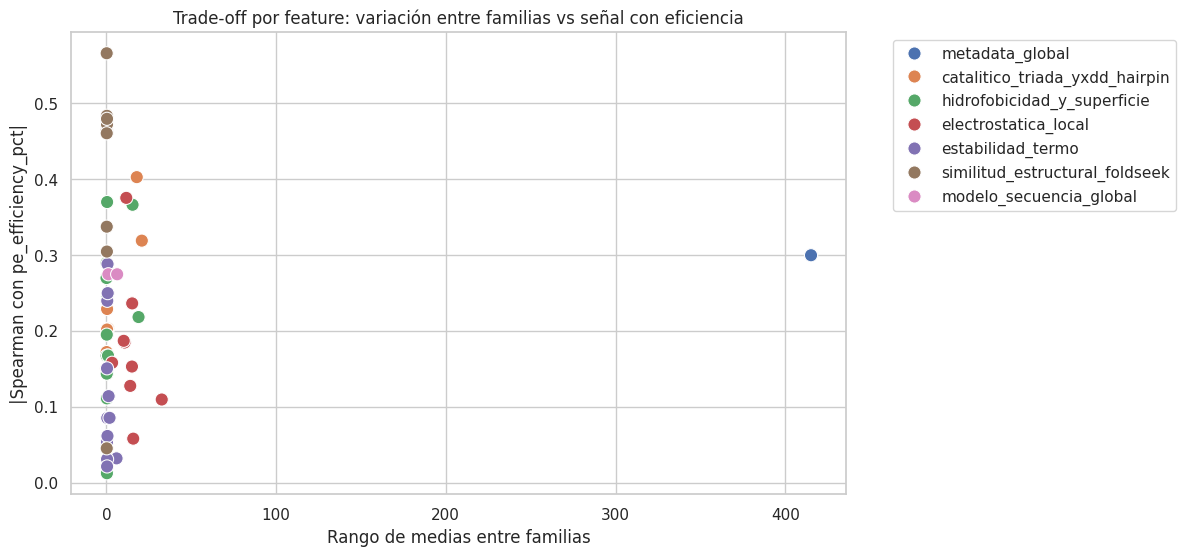

In [46]:
# ------------------------------------------------------------
# 14. Visualizar trade-off: señal vs sesgo de familia
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=family_bias_df,
    x="range_family_mean",
    y="abs_eff",
    hue="block",
    s=90
)

plt.title("Trade-off por feature: variación entre familias vs señal con eficiencia")
plt.xlabel("Rango de medias entre familias")
plt.ylabel("|Spearman con pe_efficiency_pct|")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## 16) Top features por bloque

In [47]:
# ------------------------------------------------------------
# 15. Top 5 features por bloque según eficiencia y actividad
# ------------------------------------------------------------
for block_name, summary_df in block_summaries.items():
    if summary_df is None or len(summary_df) == 0:
        continue
    
    print("\n" + "="*100)
    print(f"TOP FEATURES - {block_name}")
    print("="*100)
    
    print("\nTop por |Spearman con pe_efficiency_pct|")
    display(summary_df.sort_values("abs_eff", ascending=False).head(5))
    
    print("\nTop por |Spearman con active|")
    display(summary_df.sort_values("abs_act", ascending=False).head(5))


TOP FEATURES - metadata_global

Top por |Spearman con pe_efficiency_pct|


,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
0,n_residues,0.0,0.299960,0.221098,0.299960,0.221098
1,protein_length_aa,0.0,0.299627,0.219982,0.299627,0.219982
2,seq_length,0.0,0.299627,0.219982,0.299627,0.219982



Top por |Spearman con active|


,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
0,n_residues,0.0,0.299960,0.221098,0.299960,0.221098
1,protein_length_aa,0.0,0.299627,0.219982,0.299627,0.219982
2,seq_length,0.0,0.299627,0.219982,0.299627,0.219982



TOP FEATURES - catalitico_triada_yxdd_hairpin

Top por |Spearman con pe_efficiency_pct|


...

,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
8,foldseek_best_TM,0.0,0.565791,0.550472,0.565791,0.550472
2,foldseek_TM_LTRRetrotransposon,0.0,0.464279,0.459832,0.464279,0.459832
9,foldseek_best_fident,0.0,0.479394,0.458793,0.479394,0.458793
7,foldseek_best_LDDT,0.0,0.460337,0.433296,0.460337,0.433296
1,foldseek_TM_HIV1,0.0,0.483382,0.400136,0.483382,0.400136



TOP FEATURES - modelo_secuencia_global

Top por |Spearman con pe_efficiency_pct|


,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
0,log_likelihood,0.0,0.274549,0.249804,0.274549,0.249804
1,perplexity,0.0,-0.274549,-0.249804,0.274549,0.249804



Top por |Spearman con active|


,feature,missing_pct,spearman_with_efficiency,spearman_with_active,abs_eff,abs_act
0,log_likelihood,0.0,0.274549,0.249804,0.274549,0.249804
1,perplexity,0.0,-0.274549,-0.249804,0.274549,0.249804


## 17) Resumen narrativo automático

In [48]:
# ------------------------------------------------------------
# 16. Resumen automático de hallazgos por bloque
# ------------------------------------------------------------
for block_name, summary_df in block_summaries.items():
    if summary_df is None or len(summary_df) == 0:
        continue
    
    best_eff_row = summary_df.sort_values("abs_eff", ascending=False).iloc[0]
    best_act_row = summary_df.sort_values("abs_act", ascending=False).iloc[0]
    
    print(f"\nBloque: {block_name}")
    print(f"- Feature más asociada a eficiencia: {best_eff_row['feature']} "
          f"(Spearman={best_eff_row['spearman_with_efficiency']:.3f})")
    print(f"- Feature más asociada a actividad: {best_act_row['feature']} "
          f"(Spearman={best_act_row['spearman_with_active']:.3f})")
    print(f"- Missing promedio del bloque: {summary_df['missing_pct'].mean():.2f}%")


Bloque: metadata_global
- Feature más asociada a eficiencia: n_residues (Spearman=0.300)
- Feature más asociada a actividad: n_residues (Spearman=0.221)
- Missing promedio del bloque: 0.00%

Bloque: catalitico_triada_yxdd_hairpin
- Feature más asociada a eficiencia: triad_best_rmsd (Spearman=-0.403)
- Feature más asociada a actividad: triad_best_rmsd (Spearman=-0.348)
- Missing promedio del bloque: 7.14%

Bloque: hidrofobicidad_y_superficie
- Feature más asociada a eficiencia: pocket_hydrophobic_per_res (Spearman=0.370)
- Feature más asociada a actividad: sasa_per_res (Spearman=-0.323)
- Missing promedio del bloque: 2.63%

Bloque: electrostatica_local
- Feature más asociada a eficiencia: lpqg_sp_3A_mean_pot (Spearman=-0.375)
- Feature más asociada a actividad: lpqg_sp_3A_mean_pot (Spearman=-0.292)
- Missing promedio del bloque: 7.99%

Bloque: estabilidad_termo
- Feature más asociada a eficiencia: t65_raw (Spearman=0.288)
- Feature más asociada a actividad: t65_raw (Spearman=0.186)
- M